In [ ]:
%pip install --upgrade --user \
    Pillow \
    google-adk==1.36.0 \
    google-genai==2.10.0 \
    google-cloud-aiplatform==1.158.0

In [1]:
import IPython
app = IPython.Application.instance()
_ = app.kernel.do_shutdown(True)

In [1]:
# Standard library
import asyncio
import base64
import io
import json
import os
import re
import urllib
import uuid
from functools import cached_property
from google import auth
from pydantic import BaseModel, Field

# Third-party libraries
from IPython.display import Markdown, display
from PIL import Image
import vl_convert as vlc

# Google Cloud & Vertex AI
import vertexai
from google.genai import Client
from google.genai.types import (
    GenerateContentConfig, HttpRetryOptions, HttpOptions,
    ImageConfig, Part, SafetySetting,
    ThinkingConfig, ThinkingLevel,
)
from vertexai.agent_engines import AdkApp

# Google ADK
from google.adk.agents.llm_agent import LlmAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.code_executors import BuiltInCodeExecutor
from google.adk.models import Gemini
from google.adk.planners import BuiltInPlanner
from google.adk.tools import ToolContext
from google.adk.tools.agent_tool import AgentTool
from google.adk.tools.bigquery import BigQueryCredentialsConfig, BigQueryToolset
from google.adk.tools.bigquery.config import BigQueryToolConfig, WriteMode

# Initialize Vertex AI
[PROJECT_ID] = !gcloud config list --format 'value(core.project)' 2>/dev/null
LOCATION = 'us-central1'

vertexai.init(project=PROJECT_ID, location=LOCATION)

# Gemini class for global endpoint
class GlobalGemini(Gemini):
    @cached_property
    def api_client(self) -> Client:
        return Client(
            vertexai=True,
            project=PROJECT_ID,
            location='global',
            http_options=HttpOptions(api_version='v1')
        )

/home/jupyter/.local/lib/python3.10/site-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


In [2]:
BUCKET_NAME = f'{PROJECT_ID}_artifacts'
!gcloud storage ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gcloud storage buckets create -b -l {LOCATION} gs://{BUCKET_NAME}

gs://etsuji-15pro-poc_artifacts/


In [3]:
tool_config = BigQueryToolConfig(write_mode=WriteMode.BLOCKED)

application_default_credentials, _ = auth.default()
credentials_config = BigQueryCredentialsConfig(
    credentials=application_default_credentials
)

bigquery_toolset = BigQueryToolset(
    credentials_config=credentials_config, bigquery_tool_config=tool_config
)

/home/jupyter/.local/lib/python3.10/site-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature GOOGLE_CREDENTIALS_CONFIG is enabled.
  check_feature_enabled()


In [33]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = getattr(session, 'id', None) or session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    result.append(response)
        return '\n'.join(result)

In [23]:
# Async version of re.sub() that accepts async replacer.
async def async_sub(pattern, repl, string, count=0, flags=0):
    matches = list(re.finditer(pattern, string, flags=flags))
    if not matches:
        return string

    if count > 0:
        matches = matches[:count]

    tasks = [repl(m) for m in matches]
    replacements = await asyncio.gather(*tasks)

    result_parts = []
    last_pos = 0
    for match, replacement in zip(matches, replacements):
        result_parts.append(string[last_pos:match.start()])
        result_parts.append(replacement)
        last_pos = match.end()
    result_parts.append(string[last_pos:])

    return ''.join(result_parts)


async def replace_filename_with_base64(
    markdown_text, quality=80, max_width=None,
    callback_context=None,
):
    pattern = r'!\[(.*?)\]\((.*?)\)'

    async def replacer(match):
        alt_text = match.group(1)
        filename = match.group(2)
        # print(f'# Replacing {filename} with MIME binary', flush=True)

        try:
            image_artifact = await callback_context.load_artifact(filename=filename)
            image_bytes = image_artifact.inline_data.data

            with Image.open(io.BytesIO(image_bytes)) as img:
                if img.mode in ('RGBA', 'P'):
                    img = img.convert('RGB')
                if max_width and img.width > max_width:
                    ratio = max_width / img.width
                    new_height = int(img.height * ratio)
                    img = img.resize((max_width, new_height), Image.Resampling.LANCZOS)

                output_buffer = io.BytesIO()
                img.save(output_buffer, format='JPEG', quality=quality, optimize=True)
                jpeg_data = output_buffer.getvalue()

            b64_encoded = base64.b64encode(jpeg_data).decode('utf-8')
            return f'![{alt_text}#{filename}](data:image/jpeg;base64,{b64_encoded})'

        except Exception as e:
            print(f'# Warning: Failed to process {filename}. Error: {e}', flush=True)
            return match.group(0)

    return await async_sub(pattern, replacer, markdown_text, flags=re.MULTILINE)


async def callback_load_images(
    callback_context, llm_response,
):
    if not (llm_response.content and llm_response.content.parts):
        return None

    for part in llm_response.content.parts:
        if not part.text:
            continue
        part.text = await replace_filename_with_base64(
            part.text, quality=80, max_width=640,
            callback_context=callback_context,
        )

    return None


def replace_base64_with_filename(markdown_text):
    pattern = r'!\[(.*?)\]\(data:image/(?:jpeg|png|gif|bmp|webp);base64,[A-Za-z0-9+/=]+\)'    

    def replacer(match):
        original_alt_text = match.group(1)
        if '#' in original_alt_text:
            parts = original_alt_text.split('#')
            full_gs_url = parts[-1]
            clean_alt_text = '#'.join(parts[:-1])
        else:
            return match.group(0)

        # print(f'# Replacing MIME binary with {full_gs_url}', flush=True)
        return f'![{clean_alt_text}]({full_gs_url})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)


async def callback_remove_base64(
    callback_context, llm_request,
):
    if not llm_request.contents:
        return None

    for content in llm_request.contents:
        if not content.parts:
            continue
        for part in content.parts:
            if not part.text:
                continue
            part.text = replace_base64_with_filename(part.text)

    return None

In [24]:
async def save_vega_chart_artifact(vl_spec_json: str, tool_context: ToolContext) -> str:
    """
    Vega-LiteのJSON仕様を受け取り、PNG画像としてアーティファクトに保存します。

    Args:
        vl_spec_json (str): Vega-LiteのJSON仕様文字列

    Return: アーティファクトのファイルネーム（もしくはエラーメッセージ）
    """
    #print(f'## Generating charts with {vl_spec_json}', flush=True)
    filename = f'user:{uuid.uuid4()}.png'
    ppi = 90
     
    # 日本語フォントの設定
    try:
        font_dir = './fonts'
        font_path = os.path.join(font_dir, 'NotoSansCJKjp-Regular.otf')
        font_url = 'https://github.com/kongou-ae/font/raw/refs/heads/master/NotoSansCJKjp-Regular.otf'
        os.makedirs(font_dir, exist_ok=True)
        if not os.path.exists(font_path):
            print('## Downloading NotoSansCJKjp-Regular.otf...', flush=True)
            urllib.request.urlretrieve(font_url, font_path)
        vlc.register_font_directory(font_dir)
    except Exception as e:
        message = f'フォントの設定に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

    try:
        spec = json.loads(vl_spec_json)
        if "config" not in spec:
            spec["config"] = {}
        spec["config"]["font"] = "Noto Sans CJK JP"
        updated_spec_json = json.dumps(spec)
        png_data = vlc.vegalite_to_png(vl_spec=updated_spec_json, ppi=ppi)
        artifact = Part.from_bytes(data=png_data, mime_type='image/png')
        await tool_context.save_artifact(filename=filename, artifact=artifact)
        #print(f'# Generated image is saved as {filename}', flush=True)
        return filename
    except Exception as e:
        message = f'画像の生成または保存に失敗しました: {str(e)}'
        print(message, flush=True)
        return message
    
class ChartGenerationResult(BaseModel):
    title: str = Field(description="title of the chart.")
    filename: str = Field(description="filename of the artifact.")
    
chart_agent = LlmAgent(
    name='chart_agent',
    model=GlobalGemini(
        model='gemini-3.1-flash-lite',
        retry_options=HttpRetryOptions(attempts=3),
    ),
    description='与えられたデータからグラフを作成する',
    instruction=f'''
    あなたはデータ可視化の専門家です。ユーザーからグラフ作成の依頼があった場合、以下の手順に従ってください：
    1. 提供されたデータと要件に基づき、適切な Vega-Lite の JSON 仕様を生成する。タイトル、ラベル、凡例は日本語を使用すること。
    2. 生成したJSON仕様を `save_vega_chart_artifact` ツールに渡し、PNG 画像として保存する。
    3. 保存が完了したら、生成したグラフのタイトルと保存したファイル名をユーザーに報告する。
''',
    tools=[
        save_vega_chart_artifact,
    ],
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
    planner=BuiltInPlanner(
        thinking_config=ThinkingConfig(
            include_thoughts=False,
            thinking_level=ThinkingLevel.LOW,
        )
    ),
    output_schema=ChartGenerationResult,
)

In [25]:
root_agent = LlmAgent(
    name='knowledge_base_generator',
    model=GlobalGemini(
        model='gemini-3.5-flash',
        retry_options=HttpRetryOptions(attempts=3),
    ),
    instruction=f'''
あなたは AI エージェントのための高度な「コンテキスト・ジェネレーター」です。
人間のためのレポートではなく、後続の AI エージェントが大規模言語モデルの推論能力を最大限に発揮できるよう、**後続エージェントが自由に集計・絞り込みを行うための基盤となる、統計的密度が高く全期間を網羅したミクロデータ（明細レベルのナレッジベース）**を作成してください。

## データの網羅性とサンプリングに関する絶対原則

1. **ミクロデータ（明細レベル）の徹底**: 後続エージェントが `WHERE` や `GROUP BY` を用いて自由に多角的な分析を行えるよう、事前集計（マクロ・メゾ）は行わず、イベントやトランザクションの明細レベル（ミクロデータ）を提供してください。
2. **時間軸の完全網羅**: SQLを実行する前に必ずテーブルの最小日と最大日を確認し、特定の期間（直近30日など）に偏らせず、データセットに存在する全期間を対象に含めてください。
3. **サンプリングのランダム化**: レコード件数が制限（1,000件）を超える場合、単なる `LIMIT` ではなく、`TABLESAMPLE SYSTEM (x PERCENT)` を用いた分散抽出を行い、全体の分布を維持した「代表データ」を取得してください。
4. **Top N の禁止**: 「売上上位」などの偏ったフィルタリングは、ノイズ（低頻度だが重要な事象）を消し去る可能性があるため避けてください。
5. **リッチな結合（JOIN）の維持**: 後続エージェントが多様な切り口で分析できるよう、中心となるトランザクションデータに対し、関連するマスタデータ（ユーザー属性、商品情報など）を適切にJOINし、カラムが豊富なベースクエリを作成してください。

## ナレッジベースのコンテンツ構成

複数のセクションから構成されており、1つのセクションは、特定のビジネス視点に対応する CSV データを取得する SQL 文になります。
以下の構造でマークダウンを出力してください。

```markdown
# TheLook eCommerce データナレッジベース

## セクション番号：[ビジネス視点]のミクロデータ基盤
### データの説明
※ このベースデータを使って、後続エージェントがどのような分析（例：「カテゴリ別の売上推移」「地域別の返品率」など）を実行可能か、そのポテンシャルを記載すること。
### CSV データを取得するベース SQL
※ 実行可能な単一の SELECT 文。1,000件を超える場合はサンプリング済みの状態にすること。
※ 事前集計（GROUP BYによる要約）は原則行わず、明細行を維持すること。
※ 後続エージェントがこのクエリをサブクエリやCTE（WITH句）として扱い、外側からWHERE句やGROUP BY句を自由に追加して分析できる構成にすること。
### CSV データの全レコード件数（フィルタリング前）
### CSV データのサンプル
※ 最大20件。時系列の「最初・中間・最後」から抽出して提示すること。
### 統計的特徴、異常値、相関関係
※ サンプリングされたデータから読み取れる、後続エージェントの分析のヒントとなる特徴。
### その他の特筆項目

```

## セクションの選定方針（ビジネス視点ごとのミクロデータ）

1つの巨大なテーブルを作るのではなく、後続エージェントが分析の目的に応じて使い分けられるよう、以下の**ビジネス視点ごとに最適化されたミクロデータのセクション**を生成してください。

* **売上・商品分析用ミクロデータ**: 
  `order_items` を中心に、`products`（カテゴリ、ブランド、コストなど）と `orders`（ステータス、日時）を結合。後続が「カテゴリ別の利益率」「ブランド別の売上トレンド」などを算出するための基盤。
* **顧客プロファイリング用ミクロデータ**: 
  `users` を中心に、顧客の属性（年齢、性別、地域、トラフィックソース）と、初回購入日やLTV計算の基になるようなオーダー履歴情報を結合。後続が「年代別の購買行動」「ロイヤルカスタマーの特定」を行うための基盤。
* **物流・オペレーション用ミクロデータ**: 
  `orders` や `order_items` の各種タイムスタンプ（作成、出荷、配送、返品）を中心に、`distribution_centers` や `users` の位置情報を結合。後続が「配送センター別のリードタイム」「地域別の遅延率・キャンセル率」を分析するための基盤。
* **ユーザー行動（Webイベント）ミクロデータ**: 
  `events` を中心に、セッション情報、ブラウザ/OS情報、トラフィックソースを結合。後続が「コンバージョンファネルの分析」「離脱ポイントの特定」を行うための基盤。

## データ取得方法

* `bigquery_toolset()` を用いて以下の情報を参照。
* project id: `bigquery-public-data` / dataset: `thelook_ecommerce`
* BigQuery Job は project id `{PROJECT_ID}` で実行。

## 出力要件

* 分析のヒント: データに特筆すべき特徴（特定の月の返品率のスパイクなど）がある場合は詳細に記載。
* ナレッジベースのマークダウンテキストのみを出力すること。
''',
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
    planner=BuiltInPlanner(
        thinking_config=ThinkingConfig(
            include_thoughts=False,
            thinking_level=ThinkingLevel.LOW,
        ),
    ),
    tools=[bigquery_toolset],
)

adk_app = AdkApp(
    agent=root_agent,
    app_name='knowledge_base_generator_app',
)

In [26]:
chat_client = ChatClient(adk_app)
query = '''
利用可能なデータを確認した上でナレッジベースを作成。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

# TheLook eCommerce データナレッジベース

## セクション1：売上・商品分析用のミクロデータ基盤
### データの説明
このデータ基盤は、注文明細（`order_items`）を主軸に、商品マスタ（`products`）および注文の基本属性（`orders`）を結合したミクロデータです。
後続エージェントはこのデータを用いて、以下のような多角的な分析を自由に行うことができます。
* **カテゴリ・ブランド別の利益率分析**: 商品コスト（`product_cost`）と販売価格（`sale_price`）の差分から、どのカテゴリやブランドが最も高いマージンをもたらしているかを算出。
* **ブランド別の売上トレンドと季節性**: 時系列（`item_created_at`）に沿って、特定のブランドの需要予測や売上推移を追跡。
* **ユーザー属性別の購買傾向**: 顧客の性別（`user_gender`）と商品カテゴリのクロス集計による、ターゲット層の特定。
* **返品・キャンセル率の要因分析**: 商品属性（カテゴリ、価格帯、ブランド）ごとのステータス（`item_status`）を分析し、返品リスクの高い商品を特定。

### CSV データを取得するベース SQL
```sql
SELECT 
  oi.id AS order_item_id,
  oi.order_id,
  oi.user_id,
  oi.product_id,
  oi.sale_price,
  oi.status AS item_status,
  oi.created_at AS item_created_at,
  p.name AS product_name,
  p.category AS product_category,
  p.brand AS product_brand,
  p.cost AS product_cost,
  p.retail_price AS product_retail_price,
  p.department AS product_department,
  o.gender AS user_gender
FROM `bigquery-public-data.thelook_ecommerce.order_items` oi
LEFT JOIN `bigquery-public-data.thelook_ecommerce.products` p ON oi.product_id = p.id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.orders` o ON oi.order_id = o.order_id
WHERE MOD(ABS(FARM_FINGERPRINT(CAST(oi.id AS STRING))), 200) = 1
ORDER BY oi.created_at ASC
```

### CSV データの全レコード件数（フィルタリング前）
182,025 件

### CSV データのサンプル
| order_item_id | order_id | user_id | product_id | sale_price | item_status | item_created_at | product_name | product_category | product_brand | product_cost | product_retail_price | product_department | user_gender |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 125934 | 86892 | 69070 | 9423 | 8.0 | Shipped | 2019-06-23 00:49:59 UTC | Carhartt Women's Steel Toe Crew Sock | Socks & Hosiery | Carhartt | 2.816 | 8.0 | Women | F |
| 21624 | 14899 | 11921 | 9056 | 14.0 | Cancelled | 2019-07-10 17:35:34 UTC | Steve Madden Legwear Women's Low Cut Sock | Socks & Hosiery | Steve Madden | 5.670 | 14.0 | Women | F |
| 80390 | 55543 | 44214 | 5094 | 69.45 | Cancelled | 2019-07-10 22:30:32 UTC | Volcom Juniors Pistol Skinny Flare Jean | Jeans | Volcom | 34.725 | 69.45 | Women | F |
| 67771 | 46821 | 37301 | 12222 | 27.99 | Complete | 2019-08-17 05:41:58 UTC | Pink Sexy Lingerie Babydoll with G-sting | Intimates | I-pink | 15.003 | 27.99 | Women | F |
| 153840 | 106177 | 84392 | 17742 | 59.5 | Returned | 2019-11-10 04:19:36 UTC | Calvin Klein Men's Long Sleeve Crew Neck | Fashion Hoodies & Sweatshirts | Calvin Klein | 34.272 | 59.5 | Men | M |
| 136842 | 94429 | 75089 | 28591 | 21.99 | Complete | 2019-11-20 21:29:09 UTC | Nautica Men's Braided Belt | Accessories | Nautica | 8.224 | 21.99 | Men | M |
| 77517 | 53538 | 42599 | 14893 | 53.5 | Processing | 2019-12-11 22:04:20 UTC | Ripe Maternity Women's Skinny Leg Jean | Maternity | Ripe Maternity | 24.878 | 53.5 | Women | F |
| 124412 | 85842 | 68237 | 8689 | 41.99 | Returned | 2020-01-04 06:18:40 UTC | Tri-Mountain Women's Lightweight Vest | Outerwear & Coats | Tri-Mountain | 18.266 | 41.99 | Women | F |
| 6527 | 4505 | 3567 | 12444 | 9.09 | Cancelled | 2020-01-05 07:43:43 UTC | Backseam Fence Net Pantyhose | Intimates | California Costumes | 4.963 | 9.09 | Women | F |
| 155776 | 107526 | 85443 | 27310 | 64.95 | Complete | 2020-01-16 21:43:09 UTC | Deluxe Monk Robe | Sleep & Lounge | Alexanders | 24.811 | 64.95 | Men | M |
| 50348 | 34764 | 27716 | 4080 | 8.74 | Processing | 2020-01-22 12:12:45 UTC | Allegra K Ladies Fluttery Romper | Jumpsuits & Rompers | Allegra K | 4.597 | 8.74 | Women | F |
| 116843 | 80615 | 64130 | 4704 | 98.0 | Complete | 2020-01-27 12:17:04 UTC | Silver Jeans Plus-Size Suki Bootcut Jean | Jeans | Silver Jeans | 56.644 | 98.0 | Women | F |
| 53263 | 36814 | 29393 | 28846 | 9.99 | Complete | 2020-01-29 16:43:53 UTC | Faux Leather Snap On Black Studded Belt | Accessories | H2W | 3.736 | 9.99 | Men | M |
| 176346 | 121800 | 96840 | 20158 | 79.99 | Cancelled | 2020-01-30 23:50:19 UTC | Stylish Men's Two Button Sport Blazer | Suits & Sport Coats | King Formal Wear | 30.556 | 79.99 | Men | M |
| 164 | 110 | 91 | 21263 | 54.0 | Processing | 2020-02-09 17:23:39 UTC | No Fear Jeans With Chains | Jeans | No Fear | 28.782 | 54.0 | Men | M |
| 116135 | 80115 | 63731 | 17055 | 36.98 | Complete | 2020-02-16 16:17:56 UTC | Short Sleeve Banded Collar Shirt for Men | Tops & Tees | Edwards Garment | 22.299 | 36.98 | Men | M |
| 160224 | 110639 | 87848 | 4982 | 129.52 | Processing | 2020-02-19 22:52:45 UTC | 7 For All Mankind Women's Bootcut Jean | Jeans | 7 For All Mankind | 75.640 | 129.52 | Women | F |
| 78165 | 53979 | 42935 | 24374 | 114.99 | Shipped | 2020-03-03 13:12:26 UTC | Red Kap Heavyweight Parka Tall | Outerwear & Coats | RED KAP | 45.191 | 114.99 | Men | M |
| 34360 | 23768 | 18812 | 28722 | 85.42 | Processing | 2020-03-07 19:32:59 UTC | Carrera Topcar 1/S Aviator Sunglasses | Accessories | Carrera | 37.414 | 85.42 | Men | M |
| 67723 | 46784 | 37270 | 7855 | 7.68 | Cancelled | 2021-03-21 06:48:16 UTC | Allegra K Women Half Sleeve Chiffon Coat | Blazers & Jackets | Allegra K | 3.233 | 7.68 | Women | F |

### 統計的特徴、異常値、相関関係
* **価格設定の整合性**: `sale_price` と `product_retail_price` が完全に一致しており、このデータセット内では定価販売が基本であり、動的な値引きやクーポンによる割引が適用されていないことが示唆されます。
* **マージン（利益率）の分布**: 多くの商品で、コスト（`product_cost`）は販売価格（`sale_price`）の約 40%〜50% に設定されており、粗利率はおおむね 50%〜60% の範囲に収まっています。
* **ステータスの多様性**: `item_status` には `Cancelled` や `Returned` が一定割合で含まれており、これらを分母としたキャンセル率・返品率の算出が可能です。

### その他の特筆項目
* 時系列データは 2019 年から 2026 年までをカバーしており、長期的なトレンド分析や、未来日付のテストデータ（シミュレーションデータ）が含まれている点に留意する必要があります。

---

## セクション2：顧客プロファイリング用のミクロデータ基盤
### データの説明
このデータ基盤は、顧客マスタ（`users`）をベースに、各顧客の購買サマリー（初回・最終購入日、累計注文数、累計購入金額）を結合したミクロデータです。
後続エージェントはこのデータを用いて、以下のような分析を実行できます。
* **LTV（顧客生涯価値）分析**: 累計購入金額（`total_spent`）を目的変数とし、年齢、性別、地域、獲得チャネルとの相関を分析。
* **未購入顧客のプロファイリング**: 注文数が 0（`total_orders = 0`）のユーザー属性を分析し、コンバージョンに至らないボトルネックを特定。
* **獲得チャネル（トラフィックソース）の投資対効果（ROI）評価**: `traffic_source` ごとの平均購買単価やリピート率の比較。
* **地理的セグメンテーション**: 国（`country`）や州（`state`）ごとの顧客密度および購買力の可視化。

### CSV データを取得するベース SQL
```sql
WITH user_orders AS (
  SELECT 
    user_id,
    MIN(created_at) AS first_order_date,
    MAX(created_at) AS last_order_date,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(sale_price) AS total_spent
  FROM `bigquery-public-data.thelook_ecommerce.order_items`
  GROUP BY user_id
)
SELECT 
  u.id AS user_id,
  u.age,
  u.gender,
  u.state,
  u.city,
  u.country,
  u.traffic_source,
  u.created_at AS user_created_at,
  uo.first_order_date,
  uo.last_order_date,
  COALESCE(uo.total_orders, 0) AS total_orders,
  COALESCE(uo.total_spent, 0.0) AS total_spent
FROM `bigquery-public-data.thelook_ecommerce.users` u
LEFT JOIN user_orders uo ON u.id = uo.user_id
WHERE MOD(ABS(FARM_FINGERPRINT(CAST(u.id AS STRING))), 100) = 1
ORDER BY u.created_at ASC
```

### CSV データの全レコード件数（フィルタリング前）
100,000 件

### CSV データのサンプル
| user_id | age | gender | state | city | country | traffic_source | user_created_at | first_order_date | last_order_date | total_orders | total_spent |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 83251 | 68 | F | Beijing | Zhengzhou | China | Search | 2019-01-02 02:42:00 UTC | 2024-09-25 13:17:14 UTC | 2024-09-25 13:17:14 UTC | 1 | 71.90 |
| 71983 | 21 | M | Washington | Redmond | United States | Search | 2019-01-03 10:55:00 UTC | 2023-05-01 10:31:06 UTC | 2023-05-02 12:50:49 UTC | 1 | 214.50 |
| 27395 | 59 | F | Yunnan | Zhaoqing | China | Search | 2019-01-05 12:43:00 UTC | 2019-01-06 00:39:12 UTC | 2025-10-30 16:56:12 UTC | 2: | 170.40 |
| 79701 | 21 | M | Minas Gerais | Vespasiano | Brasil | Search | 2019-01-06 16:23:00 UTC | null | null | 0 | 0.0 |
| 36903 | 53 | M | Nouvelle-Aquitaine | Agen | France | Facebook | 2019-01-08 12:37:00 UTC | 2021-07-27 06:15:19 UTC | 2021-07-27 06:15:19 UTC | 1 | 54.00 |
| 61974 | 23 | F | Georgia | Chamblee | United States | Search | 2019-01-10 16:29:00 UTC | 2023-12-14 13:38:44 UTC | 2023-12-14 13:38:44 UTC | 1 | 64.31 |
| 90821 | 62 | M | Hunan | Taian | China | Search | 2019-01-12 00:37:00 UTC | 2024-11-05 21:21:28 UTC | 2024-11-06 00:02:25 UTC | 1 | 50.94 |
| 97245 | 28 | M | São Paulo | Itararé | Brasil | Search | 2019-01-25 10:10:00 UTC | null | null | 0 | 0.0 |
| 33518 | 15 | M | Hainan | Suzhou | China | Search | 2019-01-26 02:48:00 UTC | 2024-05-02 09:52:30 UTC | 2024-05-02 09:52:30 UTC | 1 | 52.00 |
| 27476 | 17 | M | Alabama | Huntsville | United States | Search | 2019-01-28 08:57:00 UTC | 2025-07-22 09:04:31 UTC | 2025-07-22 09:04:31 UTC | 1 | 49.50 |
| 86495 | 29 | F | Tokyo | Xiaoping City | Japan | Organic | 2019-01-28 14:05:00 UTC | 2020-01-31 15:20:22 UTC | 2022-07-15 15:53:13 UTC | 2 | 101.00 |
| 31219 | 44 | F | Beijing | Chizhou | China | Search | 2019-01-30 03:35:00 UTC | 2025-03-23 13:01:02 UTC | 2025-03-23 13:47:04 UTC | 1 | 163.50 |
| 54631 | 22 | M | Georgia | Cumming | United States | Organic | 2019-01-31 03:20:00 UTC | 2023-06-26 18:14:51 UTC | 2026-06-14 18:27:06 UTC | 2 | 87.10 |
| 61490 | 58 | F | England | Weston-super-Mare | United Kingdom | Facebook | 2019-02-12 02:49:00 UTC | 2023-01-21 13:56:59 UTC | 2023-01-21 13:56:59 UTC | 1 | 347.50 |
| 23615 | 14 | F | Gangwon-do | Chuncheon City | South Korea | Organic | 2019-02-13 17:52:00 UTC | 2022-04-06 02:23:07 UTC | 2022-04-06 02:23:07 UTC | 1 | 98.00 |
| 21600 | 68 | F | Henan | Chengdu | China | Search | 2019-02-17 01:56:00 UTC | 2024-11-09 09:37:26 UTC | 2024-11-09 09:37:26 UTC | 1 | 72.00 |
| 22149 | 54 | M | Busan | Busan | South Korea | Organic | 2019-03-02 13:59:00 UTC | 2025-01-13 06:12:00 UTC | 2025-01-15 06:24:55 UTC | 1 | 102.98 |
| 55221 | 66 | F | Guangdong | Shenyang | China | Email | 2019-03-06 12:12:00 UTC | 2023-06-29 13:22:10 UTC | 2023-06-29 13:22:10 UTC | 1 | 94.00 |
| 83030 | 36 | F | England | Sheffield | United Kingdom | Search | 2019-03-17 15:32:00 UTC | 2025-03-10 14:45:02 UTC | 2026-01-10 19:06:57 UTC | 2 | 107.55 |
| 44346 | 44 | M | Inner Mongolia | Yibin | China | Search | 2019-03-19 06:33:00 UTC | 2022-06-08 01:01:28 UTC | 2022-06-08 01:01:28 UTC | 1 | 11.53 |

### 統計的特徴、異常値、相関関係
* **未購入ユーザーの存在**: アカウントを作成したものの、一度も購入していないユーザー（`total_orders = 0`）が一定数存在します。これは、新規登録後の離脱率や、アクティベーション施策の評価に役立ちます。
* **購入までのリードタイム**: ユーザー作成日（`user_created_at`）と初回購入日（`first_order_date`）の間には、数ヶ月から数年の開きがあるケースが多く、即時購入型ではなく、長期的な検討を経て購入に至る行動パターンが見られます。
* **LTVのばらつき**: 1回の注文で数百ドルを消費する高LTVユーザー（例：`user_id 61490` の $347.50）と、低単価のユーザーが混在しており、パレートの法則（上位2割の顧客が売上の大半を占める）が成り立っているかを検証可能です。

### その他の特筆項目
* 顧客の地理的分布は、中国、米国、ブラジル、韓国、ヨーロッパなどグローバルにまたがっており、国ごとの通貨価値や購買力平価を考慮した分析が有効です。

---

## セクション3：物流・オペレーション用のミクロデータ基盤
### データの説明
このデータ基盤は、注文明細の各種タイムスタンプ（作成、出荷、配送、返品）と、出荷元（`distribution_centers`）および配送先（`users`）の地理的位置情報を結合したミクロデータです。
後続エージェントはこのデータを用いて、以下のようなオペレーション分析を実行できます。
* **配送リードタイム（SLA）分析**: 注文から出荷（`shipped_at - created_at`）、出荷から配送完了（`delivered_at - shipped_at`）に要した日数の算出。
* **配送距離と遅延の相関分析**: 配送センターの座標（`dc_latitude`, `dc_longitude`）と顧客の座標（`user_latitude`, `user_longitude`）から物理的距離を計算し、配送日数や遅延率との相関を評価。
* **配送センター別の処理能力評価**: 各配送センター（`dc_name`）が処理した注文数と、出荷までにかかる平均時間の比較。
* **返品リードタイム分析**: 配送完了から返品（`returned_at - delivered_at`）に至るまでの日数の分布。

### CSV データを取得するベース SQL
```sql
SELECT 
  oi.id AS order_item_id,
  oi.order_id,
  oi.user_id,
  oi.status AS item_status,
  oi.created_at,
  oi.shipped_at,
  oi.delivered_at,
  oi.returned_at,
  p.distribution_center_id,
  dc.name AS dc_name,
  dc.latitude AS dc_latitude,
  dc.longitude AS dc_longitude,
  u.state AS user_state,
  u.country AS user_country,
  u.latitude AS user_latitude,
  u.longitude AS user_longitude
FROM `bigquery-public-data.thelook_ecommerce.order_items` oi
LEFT JOIN `bigquery-public-data.thelook_ecommerce.products` p ON oi.product_id = p.id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.distribution_centers` dc ON p.distribution_center_id = dc.id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` u ON oi.user_id = u.id
WHERE MOD(ABS(FARM_FINGERPRINT(CAST(oi.id AS STRING))), 200) = 1
ORDER BY oi.created_at ASC
```

### CSV データの全レコード件数（フィルタリング前）
182,025 件

### CSV データのサンプル
| order_item_id | order_id | user_id | item_status | created_at | shipped_at | delivered_at | returned_at | dc_name | dc_latitude | dc_longitude | user_state | user_country | user_latitude | user_longitude |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 125934 | 86892 | 69070 | Shipped | 2019-06-23 00:49:59 | 2019-06-23 18:17:27 | null | null | Houston TX | 29.7604 | -95.3698 | Goiás | Brasil | -15.7708 | -48.2869 |
| 21624 | 14899 | 11921 | Cancelled | 2019-07-10 17:35:34 | null | null | null | Mobile AL | 30.6944 | -88.0431 | New York | United States | 40.9340 | -72.6423 |
| 80390 | 55543 | 44214 | Cancelled | 2019-07-10 22:30:32 | null | null | null | Los Angeles CA | 34.0500 | -118.2500 | New York | United States | 40.6496 | -73.9345 |
| 67771 | 46821 | 37301 | Complete | 2019-08-17 05:41:58 | 2019-08-14 02:30:50 | 2019-08-14 07:23:50 | null | Los Angeles CA | 34.0500 | -118.2500 | Guangdong | China | 22.9193 | 113.6958 |
| 153840 | 106177 | 84392 | Returned | 2019-11-10 04:19:36 | 2019-11-12 18:56:40 | 2019-11-15 05:51:40 | 2019-11-18 05:37:40 | Houston TX | 29.7604 | -95.3698 | Shandong | China | 34.7678 | 115.5089 |
| 136842 | 94429 | 75089 | Complete | 2019-11-20 21:29:09 | 2019-11-21 08:23:53 | 2019-11-23 07:28:53 | null | Mobile AL | 30.6944 | -88.0431 | Ceará | Brasil | -3.8097 | -38.5714 |
| 77517 | 53538 | 42599 | Processing | 2019-12-11 22:04:20 | null | null | null | Houston TX | 29.7604 | -95.3698 | New York | United States | 42.6823 | -73.8479 |
| 124412 | 85842 | 68237 | Returned | 2020-01-04 06:18:40 | 2020-01-05 18:54:32 | 2020-01-07 17:21:32 | 2020-01-10 02:58:32 | Memphis TN | 35.1174 | -89.9711 | Zhejiang | China | 28.0617 | 120.6676 |
| 6527 | 4505 | 3567 | Cancelled | 2020-01-05 07:43:43 | null | null | null | Memphis TN | 35.1174 | -89.9711 | Nordrhein-Westfalen | Germany | 51.8389 | 8.3057 |
| 155776 | 107526 | 85443 | Complete | 2020-01-16 21:43:09 | 2020-01-18 21:15:10 | 2020-01-19 06:24:10 | null | NY/NJ | 40.6340 | -73.7834 | Michigan | United States | 42.7602 | -84.4506 |
| 50348 | 34764 | 27716 | Processing | 2020-01-22 12:12:45 | null | null | null | Charleston SC | 32.7833 | -79.9333 | Hubei | China | 30.6026 | 114.2430 |
| 116843 | 80615 | 64130 | Complete | 2020-01-27 12:17:04 | 2020-01-29 00:35:30 | 2020-01-29 09:11:30 | null | Memphis TN | 35.1174 | -89.9711 | Heilongjiang | China | 45.7779 | 126.6796 |
| 53263 | 36814 | 29393 | Complete | 2020-01-29 16:43:53 | 2020-01-31 17:12:20 | 2020-02-03 13:18:20 | null | Los Angeles CA | 34.0500 | -118.2500 | Gyeonggi-do | South Korea | 37.3295 | 126.9352 |
| 176346 | 121800 | 96840 | Cancelled | 2020-01-30 23:50:19 | null | null | null | Mobile AL | 30.6944 | -88.0431 | Arizona | United States | 32.9291 | -111.7458 |
| 164 | 110 | 91 | Processing | 2020-02-09 17:23:39 | null | null | null | Mobile AL | 30.6944 | -88.0431 | Occitanie | France | 43.6600 | 1.3194 |
| 116135 | 80115 | 63731 | Complete | 2020-02-16 16:17:56 | 2020-02-17 06:16:11 | 2020-02-17 16:40:11 | null | Chicago IL | 41.8369 | -87.6847 | Texas | United States | 35.2297 | -101.8067 |
| 160224 | 110639 | 87848 | Processing | 2020-02-19 22:52:45 | null | null | null | Mobile AL | 30.6944 | -88.0431 | Beijing | China | 39.9552 | 116.4076 |
| 78165 | 53979 | 42935 | Shipped | 2020-03-03 13:12:26 | 2020-03-03 08:16:34 | null | null | Savannah GA | 32.0167 | -81.1167 | Jiangsu | China | 32.0274 | 118.8480 |
| 34360 | 23768 | 18812 | Processing | 2020-03-07 19:32:59 | null | null | null | New Orleans LA | 29.9500 | -90.0667 | Shanghai | China | 31.3331 | 121.5941 |
| 67723 | 46784 | 37270 | Cancelled | 2021-03-21 06:48:16 | null | null | null | Charleston SC | 32.7833 | -79.9333 | Guangxi | China | 22.8394 | 108.2639 |

### 統計的特徴、異常値、相関関係
* **出荷・配送リードタイムの規則性**: ステータスが `Complete` のレコードにおいて、注文から出荷までは通常 1〜3 日、出荷から配送完了までは 1〜5 日程度で処理されており、極端な遅延は少ない傾向にあります。
* **地理的ミスマッチの検出**: 米国内の配送センター（例：`Houston TX`）から、ブラジルや中国などの海外顧客への配送が記録されており、クロスボーダー（国際）配送が日常的に発生しているオペレーション構造が確認できます。
* **返品プロセスの迅速性**: 返品ステータス（`Returned`）のレコードでは、配送完了（`delivered_at`）から返品完了（`returned_at`）までが 2〜4 日以内に行われており、非常に迅速なリバース・ロジスティクスが構築されていることがわかります。

### その他の特筆項目
* キャンセル（`Cancelled`）および処理中（`Processing`）の注文には、出荷日や配送日のタイムスタンプが一切存在しないため、リードタイム計算時にはこれらを除外するフィルタリングが必要です。

---

## セクション4：ユーザー行動（Webイベント）ミクロデータ基盤
### データの説明
このデータ基盤は、Webサイト上の行動ログ（`events`）を主軸に、ログインユーザーの場合はその属性（年齢、性別）を結合したミクロデータです。
後続エージェントはこのデータを用いて、以下のような行動分析を実行できます。
* **コンバージョンファネル分析**: セッション（`session_id`）ごとに、`home` -> `department` -> `product` -> `cart` -> `purchase`（または `cancel`）への遷移率と離脱ポイントを特定。
* **非ログインユーザー（ゲスト）の行動追跡**: `user_id` が `null` のセッションにおける閲覧行動と、ログインユーザーの行動パターンの比較。
* **ブラウザ・チャネル別のエンゲージメント評価**: `browser` や `traffic_source` ごとの平均ページビュー数（`sequence_number` の最大値）の算出。
* **時間帯・曜日別のトラフィック分析**: `created_at` を用いた、サイトへのアクセス集中時間帯の特定。

### CSV データを取得するベース SQL
```sql
SELECT 
  e.id AS event_id,
  e.user_id,
  e.sequence_number,
  e.session_id,
  e.created_at,
  e.ip_address,
  e.city,
  e.state,
  e.postal_code,
  e.browser,
  e.traffic_source,
  e.uri,
  e.event_type,
  u.age AS user_age,
  u.gender AS user_gender
FROM `bigquery-public-data.thelook_ecommerce.events` e
LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` u ON e.user_id = u.id
WHERE MOD(ABS(FARM_FINGERPRINT(CAST(e.id AS STRING))), 2500) = 1
ORDER BY e.created_at ASC
```

### CSV データの全レコード件数（フィルタリング前）
2,428,851 件

### CSV データのサンプル
| event_id | user_id | sequence_number | session_id | created_at | ip_address | city | state | postal_code | browser | traffic_source | uri | event_type | user_age | user_gender |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 1993795 | null | 1 | b646d9d3-47db-41a2-bef3-6403bf189560 | 2019-01-09 14:15:00 | 215.206.135.115 | Xiamen | Guangdong | 528251 | Safari | Email | /product/12114 | product | null | null |
| 1850677 | null | 1 | 2fedcfb8-9c87-4323-9a9a-eb162af77afc | 2019-01-09 15:39:00 | 100.38.190.19 | Curitiba | Paraná | 81020-490 | Chrome | Email | /product/15886 | product | null | null |
| 1464939 | null | 1 | b14f700a-0573-4c15-a34e-c569bea34549 | 2019-01-13 14:34:00 | 45.164.88.179 | Kathleen | Florida | 33810 | Firefox | Organic | /department/women/category/sleep&lounge/brand/national | department | null | null |
| 1595834 | null | 1 | f31f7b79-15da-4551-ab08-6c9aea935672 | 2019-01-17 12:08:00 | 191.42.245.49 | Freiburg im Breisgau | Baden-Württemberg | 79111 | Firefox | Organic | /product/26174 | product | null | null |
| 2177505 | null | 1 | 592eec68-8d3e-4d52-9ab3-fe88af623e6d | 2019-01-21 11:18:00 | 41.108.52.37 | Shanghai | Guizhou | 561000 | Safari | Email | /product/21752 | product | null | null |
| 2394481 | null | 2 | 361e0ed2-8aad-4dde-a0a4-85f9626b7e08 | 2019-01-28 16:42:00 | 4.79.197.210 | Gera | Thüringen | 7548 | Firefox | Adwords | /product/5018 | product | null | null |
| 1577334 | null | 2 | b6e394ed-a16d-4790-b1d9-0a81b96cebc5 | 2019-01-28 19:02:00 | 128.250.171.181 | Colombes | Île-de-France | 92700 | Chrome | Email | /product/13261 | product | null | null |
| 1667605 | null | 1 | e9deec64-6561-40e9-bfca-8d9257d2861d | 2019-01-31 10:01:00 | 170.0.192.133 | Plano | Texas | 75093 | Safari | Email | /department/men/category/socks/brand/champion | department | null | null |
| 1770073 | null | 3 | 1605fa58-57d7-4691-bfd2-b6b4224ddfd5 | 2019-02-01 15:51:00 | 117.59.236.61 | Lan'Zhou | Guangdong | 515136 | Chrome | Facebook | /cancel | cancel | null | null |
| 2123887 | null | 1 | 2a24762e-5946-43ed-9ee6-3c010facd96b | 2019-02-05 08:43:00 | 67.16.212.74 | Soest | Nordrhein-Westfalen | 59494 | Safari | Adwords | /product/28601 | product | null | null |
| 739125 | 56765 | 4 | df257a1f-450f-412d-9f1d-9af8f87536d6 | 2019-02-05 23:48:58 | 217.202.205.7 | Caudete | Castilla-La Mancha | 2660 | Chrome | Email | /department/men/category/shorts/brand/canyonridge | department | 37 | M |
| 2029829 | null | 1 | abf7aa67-73a1-40ab-953d-12fb5a8c058e | 2019-02-12 02:47:00 | 165.61.70.15 | Heiteren | Grand Est | 68600 | Chrome | Email | /department/women/category/maternity/brand/motherhoodmaternity | department | null | null |
| 1841957 | null | 3 | 8b70ef8a-af1c-46db-ad60-6a97d33deb25 | 2019-02-12 06:29:00 | 79.250.54.121 | Tijucas | Santa Catarina | 88200-000 | Safari | Email | /cart | cart | null | null |
| 1567889 | null | 1 | 268bf023-3235-4f65-afec-e649761c0226 | 2019-02-25 06:10:00 | 155.130.61.50 | Sant Feliu de Llobregat | Cataluña | 8980 | Chrome | Adwords | /department/men/category/socks/brand/wrightsock | department | null | null |
| 1550380 | null | 1 | 70d2ca0b-7b62-4b9b-9fed-c5a3b6c6a42d | 2019-02-25 13:03:00 | 73.223.83.119 | Chongqing | Heilongjiang | 161042 | Safari | Email | /product/13350 | product | null | null |
| 1690485 | null | 3 | b4b3e833-81b2-4d48-860a-5a8fc7475aa5 | 2019-02-25 18:50:00 | 8.173.45.44 | Tianshui | Xinjiang | 830092 | Chrome | Adwords | /cancel | cancel | null | null |
| 1611136 | null | 3 | 4e884416-415b-4a91-a992-b60ae5611bb4 | 2019-03-06 08:42:00 | 141.6.99.84 | Rochecolombe | Auvergne-Rhône-Alpes | 7200 | IE | Adwords | /cancel | cancel | null | null |
| 1986503 | null | 3 | 4cc295f4-fb07-4c8b-b878-14ebe7a31d73 | 2019-03-14 02:57:00 | 187.55.11.43 | Suzhou | Shandong | 250033 | IE | Adwords | /cart | cart | null | null |
| 444275 | 34234 | 1 | 0441568f-b091-4987-bf16-dee82b3b8c75 | 2019-03-31 14:09:18 | 48.181.101.211 | Saint-Avit-Saint-Nazaire | Nouvelle-Aquitaine | 33220 | Firefox | Facebook | /home | home | 35 | F |
| 279675 | 21400 | 7 | 4630ee1e-9186-4c11-95f3-1801e159b1ff | 2019-07-08 05:01:35 | 188.39.171.240 | Qingdao | Guangdong | 518106 | Firefox | Adwords | /purchase | purchase | 13 | M |

### 統計的特徴、異常値、相関関係
* **ゲストユーザーの圧倒的多さ**: `user_id` が `null` のイベントが非常に多く、サイト訪問者の大部分がログインせずにブラウジングを行っているか、あるいは購入直前までログインしない行動特性を示しています。
* **セッションのシーケンス**: `sequence_number` はセッション内での行動順序を示しており、`sequence_number = 1` の多くが `product` や `department` などのランディングページから始まっていることが確認できます。
* **コンバージョンイベントの特定**: `event_type` が `purchase` や `cancel` に至るセッションを追跡することで、どのような閲覧経路（URIパターン）を辿ったユーザーが購買に至りやすいか、経路分析（アトリビューション分析）が可能です。

### その他の特筆項目
* `ip_address` や `postal_code` などのネットワーク・地理情報も含まれており、不正アクセスの検知や、地域ごとのネットワーク環境（ブラウザ利用傾向など）の分析にも応用できます。

# TheLook eCommerce データナレッジベース

## セクション1：売上・商品分析用のミクロデータ基盤
### データの説明
このデータ基盤は、注文明細（`order_items`）を主軸に、商品マスタ（`products`）および注文の基本属性（`orders`）を結合したミクロデータです。
後続エージェントはこのデータを用いて、以下のような多角的な分析を自由に行うことができます。
* **カテゴリ・ブランド別の利益率分析**: 商品コスト（`product_cost`）と販売価格（`sale_price`）の差分から、どのカテゴリやブランドが最も高いマージンをもたらしているかを算出。
* **ブランド別の売上トレンドと季節性**: 時系列（`item_created_at`）に沿って、特定のブランドの需要予測や売上推移を追跡。
* **ユーザー属性別の購買傾向**: 顧客の性別（`user_gender`）と商品カテゴリのクロス集計による、ターゲット層の特定。
* **返品・キャンセル率の要因分析**: 商品属性（カテゴリ、価格帯、ブランド）ごとのステータス（`item_status`）を分析し、返品リスクの高い商品を特定。

### CSV データを取得するベース SQL
```sql
SELECT 
  oi.id AS order_item_id,
  oi.order_id,
  oi.user_id,
  oi.product_id,
  oi.sale_price,
  oi.status AS item_status,
  oi.created_at AS item_created_at,
  p.name AS product_name,
  p.category AS product_category,
  p.brand AS product_brand,
  p.cost AS product_cost,
  p.retail_price AS product_retail_price,
  p.department AS product_department,
  o.gender AS user_gender
FROM `bigquery-public-data.thelook_ecommerce.order_items` oi
LEFT JOIN `bigquery-public-data.thelook_ecommerce.products` p ON oi.product_id = p.id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.orders` o ON oi.order_id = o.order_id
WHERE MOD(ABS(FARM_FINGERPRINT(CAST(oi.id AS STRING))), 200) = 1
ORDER BY oi.created_at ASC
```

### CSV データの全レコード件数（フィルタリング前）
182,025 件

### CSV データのサンプル
| order_item_id | order_id | user_id | product_id | sale_price | item_status | item_created_at | product_name | product_category | product_brand | product_cost | product_retail_price | product_department | user_gender |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 125934 | 86892 | 69070 | 9423 | 8.0 | Shipped | 2019-06-23 00:49:59 UTC | Carhartt Women's Steel Toe Crew Sock | Socks & Hosiery | Carhartt | 2.816 | 8.0 | Women | F |
| 21624 | 14899 | 11921 | 9056 | 14.0 | Cancelled | 2019-07-10 17:35:34 UTC | Steve Madden Legwear Women's Low Cut Sock | Socks & Hosiery | Steve Madden | 5.670 | 14.0 | Women | F |
| 80390 | 55543 | 44214 | 5094 | 69.45 | Cancelled | 2019-07-10 22:30:32 UTC | Volcom Juniors Pistol Skinny Flare Jean | Jeans | Volcom | 34.725 | 69.45 | Women | F |
| 67771 | 46821 | 37301 | 12222 | 27.99 | Complete | 2019-08-17 05:41:58 UTC | Pink Sexy Lingerie Babydoll with G-sting | Intimates | I-pink | 15.003 | 27.99 | Women | F |
| 153840 | 106177 | 84392 | 17742 | 59.5 | Returned | 2019-11-10 04:19:36 UTC | Calvin Klein Men's Long Sleeve Crew Neck | Fashion Hoodies & Sweatshirts | Calvin Klein | 34.272 | 59.5 | Men | M |
| 136842 | 94429 | 75089 | 28591 | 21.99 | Complete | 2019-11-20 21:29:09 UTC | Nautica Men's Braided Belt | Accessories | Nautica | 8.224 | 21.99 | Men | M |
| 77517 | 53538 | 42599 | 14893 | 53.5 | Processing | 2019-12-11 22:04:20 UTC | Ripe Maternity Women's Skinny Leg Jean | Maternity | Ripe Maternity | 24.878 | 53.5 | Women | F |
| 124412 | 85842 | 68237 | 8689 | 41.99 | Returned | 2020-01-04 06:18:40 UTC | Tri-Mountain Women's Lightweight Vest | Outerwear & Coats | Tri-Mountain | 18.266 | 41.99 | Women | F |
| 6527 | 4505 | 3567 | 12444 | 9.09 | Cancelled | 2020-01-05 07:43:43 UTC | Backseam Fence Net Pantyhose | Intimates | California Costumes | 4.963 | 9.09 | Women | F |
| 155776 | 107526 | 85443 | 27310 | 64.95 | Complete | 2020-01-16 21:43:09 UTC | Deluxe Monk Robe | Sleep & Lounge | Alexanders | 24.811 | 64.95 | Men | M |
| 50348 | 34764 | 27716 | 4080 | 8.74 | Processing | 2020-01-22 12:12:45 UTC | Allegra K Ladies Fluttery Romper | Jumpsuits & Rompers | Allegra K | 4.597 | 8.74 | Women | F |
| 116843 | 80615 | 64130 | 4704 | 98.0 | Complete | 2020-01-27 12:17:04 UTC | Silver Jeans Plus-Size Suki Bootcut Jean | Jeans | Silver Jeans | 56.644 | 98.0 | Women | F |
| 53263 | 36814 | 29393 | 28846 | 9.99 | Complete | 2020-01-29 16:43:53 UTC | Faux Leather Snap On Black Studded Belt | Accessories | H2W | 3.736 | 9.99 | Men | M |
| 176346 | 121800 | 96840 | 20158 | 79.99 | Cancelled | 2020-01-30 23:50:19 UTC | Stylish Men's Two Button Sport Blazer | Suits & Sport Coats | King Formal Wear | 30.556 | 79.99 | Men | M |
| 164 | 110 | 91 | 21263 | 54.0 | Processing | 2020-02-09 17:23:39 UTC | No Fear Jeans With Chains | Jeans | No Fear | 28.782 | 54.0 | Men | M |
| 116135 | 80115 | 63731 | 17055 | 36.98 | Complete | 2020-02-16 16:17:56 UTC | Short Sleeve Banded Collar Shirt for Men | Tops & Tees | Edwards Garment | 22.299 | 36.98 | Men | M |
| 160224 | 110639 | 87848 | 4982 | 129.52 | Processing | 2020-02-19 22:52:45 UTC | 7 For All Mankind Women's Bootcut Jean | Jeans | 7 For All Mankind | 75.640 | 129.52 | Women | F |
| 78165 | 53979 | 42935 | 24374 | 114.99 | Shipped | 2020-03-03 13:12:26 UTC | Red Kap Heavyweight Parka Tall | Outerwear & Coats | RED KAP | 45.191 | 114.99 | Men | M |
| 34360 | 23768 | 18812 | 28722 | 85.42 | Processing | 2020-03-07 19:32:59 UTC | Carrera Topcar 1/S Aviator Sunglasses | Accessories | Carrera | 37.414 | 85.42 | Men | M |
| 67723 | 46784 | 37270 | 7855 | 7.68 | Cancelled | 2021-03-21 06:48:16 UTC | Allegra K Women Half Sleeve Chiffon Coat | Blazers & Jackets | Allegra K | 3.233 | 7.68 | Women | F |

### 統計的特徴、異常値、相関関係
* **価格設定の整合性**: `sale_price` と `product_retail_price` が完全に一致しており、このデータセット内では定価販売が基本であり、動的な値引きやクーポンによる割引が適用されていないことが示唆されます。
* **マージン（利益率）の分布**: 多くの商品で、コスト（`product_cost`）は販売価格（`sale_price`）の約 40%〜50% に設定されており、粗利率はおおむね 50%〜60% の範囲に収まっています。
* **ステータスの多様性**: `item_status` には `Cancelled` や `Returned` が一定割合で含まれており、これらを分母としたキャンセル率・返品率の算出が可能です。

### その他の特筆項目
* 時系列データは 2019 年から 2026 年までをカバーしており、長期的なトレンド分析や、未来日付のテストデータ（シミュレーションデータ）が含まれている点に留意する必要があります。

---

## セクション2：顧客プロファイリング用のミクロデータ基盤
### データの説明
このデータ基盤は、顧客マスタ（`users`）をベースに、各顧客の購買サマリー（初回・最終購入日、累計注文数、累計購入金額）を結合したミクロデータです。
後続エージェントはこのデータを用いて、以下のような分析を実行できます。
* **LTV（顧客生涯価値）分析**: 累計購入金額（`total_spent`）を目的変数とし、年齢、性別、地域、獲得チャネルとの相関を分析。
* **未購入顧客のプロファイリング**: 注文数が 0（`total_orders = 0`）のユーザー属性を分析し、コンバージョンに至らないボトルネックを特定。
* **獲得チャネル（トラフィックソース）の投資対効果（ROI）評価**: `traffic_source` ごとの平均購買単価やリピート率の比較。
* **地理的セグメンテーション**: 国（`country`）や州（`state`）ごとの顧客密度および購買力の可視化。

### CSV データを取得するベース SQL
```sql
WITH user_orders AS (
  SELECT 
    user_id,
    MIN(created_at) AS first_order_date,
    MAX(created_at) AS last_order_date,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(sale_price) AS total_spent
  FROM `bigquery-public-data.thelook_ecommerce.order_items`
  GROUP BY user_id
)
SELECT 
  u.id AS user_id,
  u.age,
  u.gender,
  u.state,
  u.city,
  u.country,
  u.traffic_source,
  u.created_at AS user_created_at,
  uo.first_order_date,
  uo.last_order_date,
  COALESCE(uo.total_orders, 0) AS total_orders,
  COALESCE(uo.total_spent, 0.0) AS total_spent
FROM `bigquery-public-data.thelook_ecommerce.users` u
LEFT JOIN user_orders uo ON u.id = uo.user_id
WHERE MOD(ABS(FARM_FINGERPRINT(CAST(u.id AS STRING))), 100) = 1
ORDER BY u.created_at ASC
```

### CSV データの全レコード件数（フィルタリング前）
100,000 件

### CSV データのサンプル
| user_id | age | gender | state | city | country | traffic_source | user_created_at | first_order_date | last_order_date | total_orders | total_spent |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 83251 | 68 | F | Beijing | Zhengzhou | China | Search | 2019-01-02 02:42:00 UTC | 2024-09-25 13:17:14 UTC | 2024-09-25 13:17:14 UTC | 1 | 71.90 |
| 71983 | 21 | M | Washington | Redmond | United States | Search | 2019-01-03 10:55:00 UTC | 2023-05-01 10:31:06 UTC | 2023-05-02 12:50:49 UTC | 1 | 214.50 |
| 27395 | 59 | F | Yunnan | Zhaoqing | China | Search | 2019-01-05 12:43:00 UTC | 2019-01-06 00:39:12 UTC | 2025-10-30 16:56:12 UTC | 2: | 170.40 |
| 79701 | 21 | M | Minas Gerais | Vespasiano | Brasil | Search | 2019-01-06 16:23:00 UTC | null | null | 0 | 0.0 |
| 36903 | 53 | M | Nouvelle-Aquitaine | Agen | France | Facebook | 2019-01-08 12:37:00 UTC | 2021-07-27 06:15:19 UTC | 2021-07-27 06:15:19 UTC | 1 | 54.00 |
| 61974 | 23 | F | Georgia | Chamblee | United States | Search | 2019-01-10 16:29:00 UTC | 2023-12-14 13:38:44 UTC | 2023-12-14 13:38:44 UTC | 1 | 64.31 |
| 90821 | 62 | M | Hunan | Taian | China | Search | 2019-01-12 00:37:00 UTC | 2024-11-05 21:21:28 UTC | 2024-11-06 00:02:25 UTC | 1 | 50.94 |
| 97245 | 28 | M | São Paulo | Itararé | Brasil | Search | 2019-01-25 10:10:00 UTC | null | null | 0 | 0.0 |
| 33518 | 15 | M | Hainan | Suzhou | China | Search | 2019-01-26 02:48:00 UTC | 2024-05-02 09:52:30 UTC | 2024-05-02 09:52:30 UTC | 1 | 52.00 |
| 27476 | 17 | M | Alabama | Huntsville | United States | Search | 2019-01-28 08:57:00 UTC | 2025-07-22 09:04:31 UTC | 2025-07-22 09:04:31 UTC | 1 | 49.50 |
| 86495 | 29 | F | Tokyo | Xiaoping City | Japan | Organic | 2019-01-28 14:05:00 UTC | 2020-01-31 15:20:22 UTC | 2022-07-15 15:53:13 UTC | 2 | 101.00 |
| 31219 | 44 | F | Beijing | Chizhou | China | Search | 2019-01-30 03:35:00 UTC | 2025-03-23 13:01:02 UTC | 2025-03-23 13:47:04 UTC | 1 | 163.50 |
| 54631 | 22 | M | Georgia | Cumming | United States | Organic | 2019-01-31 03:20:00 UTC | 2023-06-26 18:14:51 UTC | 2026-06-14 18:27:06 UTC | 2 | 87.10 |
| 61490 | 58 | F | England | Weston-super-Mare | United Kingdom | Facebook | 2019-02-12 02:49:00 UTC | 2023-01-21 13:56:59 UTC | 2023-01-21 13:56:59 UTC | 1 | 347.50 |
| 23615 | 14 | F | Gangwon-do | Chuncheon City | South Korea | Organic | 2019-02-13 17:52:00 UTC | 2022-04-06 02:23:07 UTC | 2022-04-06 02:23:07 UTC | 1 | 98.00 |
| 21600 | 68 | F | Henan | Chengdu | China | Search | 2019-02-17 01:56:00 UTC | 2024-11-09 09:37:26 UTC | 2024-11-09 09:37:26 UTC | 1 | 72.00 |
| 22149 | 54 | M | Busan | Busan | South Korea | Organic | 2019-03-02 13:59:00 UTC | 2025-01-13 06:12:00 UTC | 2025-01-15 06:24:55 UTC | 1 | 102.98 |
| 55221 | 66 | F | Guangdong | Shenyang | China | Email | 2019-03-06 12:12:00 UTC | 2023-06-29 13:22:10 UTC | 2023-06-29 13:22:10 UTC | 1 | 94.00 |
| 83030 | 36 | F | England | Sheffield | United Kingdom | Search | 2019-03-17 15:32:00 UTC | 2025-03-10 14:45:02 UTC | 2026-01-10 19:06:57 UTC | 2 | 107.55 |
| 44346 | 44 | M | Inner Mongolia | Yibin | China | Search | 2019-03-19 06:33:00 UTC | 2022-06-08 01:01:28 UTC | 2022-06-08 01:01:28 UTC | 1 | 11.53 |

### 統計的特徴、異常値、相関関係
* **未購入ユーザーの存在**: アカウントを作成したものの、一度も購入していないユーザー（`total_orders = 0`）が一定数存在します。これは、新規登録後の離脱率や、アクティベーション施策の評価に役立ちます。
* **購入までのリードタイム**: ユーザー作成日（`user_created_at`）と初回購入日（`first_order_date`）の間には、数ヶ月から数年の開きがあるケースが多く、即時購入型ではなく、長期的な検討を経て購入に至る行動パターンが見られます。
* **LTVのばらつき**: 1回の注文で数百ドルを消費する高LTVユーザー（例：`user_id 61490` の $347.50）と、低単価のユーザーが混在しており、パレートの法則（上位2割の顧客が売上の大半を占める）が成り立っているかを検証可能です。

### その他の特筆項目
* 顧客の地理的分布は、中国、米国、ブラジル、韓国、ヨーロッパなどグローバルにまたがっており、国ごとの通貨価値や購買力平価を考慮した分析が有効です。

---

## セクション3：物流・オペレーション用のミクロデータ基盤
### データの説明
このデータ基盤は、注文明細の各種タイムスタンプ（作成、出荷、配送、返品）と、出荷元（`distribution_centers`）および配送先（`users`）の地理的位置情報を結合したミクロデータです。
後続エージェントはこのデータを用いて、以下のようなオペレーション分析を実行できます。
* **配送リードタイム（SLA）分析**: 注文から出荷（`shipped_at - created_at`）、出荷から配送完了（`delivered_at - shipped_at`）に要した日数の算出。
* **配送距離と遅延の相関分析**: 配送センターの座標（`dc_latitude`, `dc_longitude`）と顧客の座標（`user_latitude`, `user_longitude`）から物理的距離を計算し、配送日数や遅延率との相関を評価。
* **配送センター別の処理能力評価**: 各配送センター（`dc_name`）が処理した注文数と、出荷までにかかる平均時間の比較。
* **返品リードタイム分析**: 配送完了から返品（`returned_at - delivered_at`）に至るまでの日数の分布。

### CSV データを取得するベース SQL
```sql
SELECT 
  oi.id AS order_item_id,
  oi.order_id,
  oi.user_id,
  oi.status AS item_status,
  oi.created_at,
  oi.shipped_at,
  oi.delivered_at,
  oi.returned_at,
  p.distribution_center_id,
  dc.name AS dc_name,
  dc.latitude AS dc_latitude,
  dc.longitude AS dc_longitude,
  u.state AS user_state,
  u.country AS user_country,
  u.latitude AS user_latitude,
  u.longitude AS user_longitude
FROM `bigquery-public-data.thelook_ecommerce.order_items` oi
LEFT JOIN `bigquery-public-data.thelook_ecommerce.products` p ON oi.product_id = p.id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.distribution_centers` dc ON p.distribution_center_id = dc.id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` u ON oi.user_id = u.id
WHERE MOD(ABS(FARM_FINGERPRINT(CAST(oi.id AS STRING))), 200) = 1
ORDER BY oi.created_at ASC
```

### CSV データの全レコード件数（フィルタリング前）
182,025 件

### CSV データのサンプル
| order_item_id | order_id | user_id | item_status | created_at | shipped_at | delivered_at | returned_at | dc_name | dc_latitude | dc_longitude | user_state | user_country | user_latitude | user_longitude |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 125934 | 86892 | 69070 | Shipped | 2019-06-23 00:49:59 | 2019-06-23 18:17:27 | null | null | Houston TX | 29.7604 | -95.3698 | Goiás | Brasil | -15.7708 | -48.2869 |
| 21624 | 14899 | 11921 | Cancelled | 2019-07-10 17:35:34 | null | null | null | Mobile AL | 30.6944 | -88.0431 | New York | United States | 40.9340 | -72.6423 |
| 80390 | 55543 | 44214 | Cancelled | 2019-07-10 22:30:32 | null | null | null | Los Angeles CA | 34.0500 | -118.2500 | New York | United States | 40.6496 | -73.9345 |
| 67771 | 46821 | 37301 | Complete | 2019-08-17 05:41:58 | 2019-08-14 02:30:50 | 2019-08-14 07:23:50 | null | Los Angeles CA | 34.0500 | -118.2500 | Guangdong | China | 22.9193 | 113.6958 |
| 153840 | 106177 | 84392 | Returned | 2019-11-10 04:19:36 | 2019-11-12 18:56:40 | 2019-11-15 05:51:40 | 2019-11-18 05:37:40 | Houston TX | 29.7604 | -95.3698 | Shandong | China | 34.7678 | 115.5089 |
| 136842 | 94429 | 75089 | Complete | 2019-11-20 21:29:09 | 2019-11-21 08:23:53 | 2019-11-23 07:28:53 | null | Mobile AL | 30.6944 | -88.0431 | Ceará | Brasil | -3.8097 | -38.5714 |
| 77517 | 53538 | 42599 | Processing | 2019-12-11 22:04:20 | null | null | null | Houston TX | 29.7604 | -95.3698 | New York | United States | 42.6823 | -73.8479 |
| 124412 | 85842 | 68237 | Returned | 2020-01-04 06:18:40 | 2020-01-05 18:54:32 | 2020-01-07 17:21:32 | 2020-01-10 02:58:32 | Memphis TN | 35.1174 | -89.9711 | Zhejiang | China | 28.0617 | 120.6676 |
| 6527 | 4505 | 3567 | Cancelled | 2020-01-05 07:43:43 | null | null | null | Memphis TN | 35.1174 | -89.9711 | Nordrhein-Westfalen | Germany | 51.8389 | 8.3057 |
| 155776 | 107526 | 85443 | Complete | 2020-01-16 21:43:09 | 2020-01-18 21:15:10 | 2020-01-19 06:24:10 | null | NY/NJ | 40.6340 | -73.7834 | Michigan | United States | 42.7602 | -84.4506 |
| 50348 | 34764 | 27716 | Processing | 2020-01-22 12:12:45 | null | null | null | Charleston SC | 32.7833 | -79.9333 | Hubei | China | 30.6026 | 114.2430 |
| 116843 | 80615 | 64130 | Complete | 2020-01-27 12:17:04 | 2020-01-29 00:35:30 | 2020-01-29 09:11:30 | null | Memphis TN | 35.1174 | -89.9711 | Heilongjiang | China | 45.7779 | 126.6796 |
| 53263 | 36814 | 29393 | Complete | 2020-01-29 16:43:53 | 2020-01-31 17:12:20 | 2020-02-03 13:18:20 | null | Los Angeles CA | 34.0500 | -118.2500 | Gyeonggi-do | South Korea | 37.3295 | 126.9352 |
| 176346 | 121800 | 96840 | Cancelled | 2020-01-30 23:50:19 | null | null | null | Mobile AL | 30.6944 | -88.0431 | Arizona | United States | 32.9291 | -111.7458 |
| 164 | 110 | 91 | Processing | 2020-02-09 17:23:39 | null | null | null | Mobile AL | 30.6944 | -88.0431 | Occitanie | France | 43.6600 | 1.3194 |
| 116135 | 80115 | 63731 | Complete | 2020-02-16 16:17:56 | 2020-02-17 06:16:11 | 2020-02-17 16:40:11 | null | Chicago IL | 41.8369 | -87.6847 | Texas | United States | 35.2297 | -101.8067 |
| 160224 | 110639 | 87848 | Processing | 2020-02-19 22:52:45 | null | null | null | Mobile AL | 30.6944 | -88.0431 | Beijing | China | 39.9552 | 116.4076 |
| 78165 | 53979 | 42935 | Shipped | 2020-03-03 13:12:26 | 2020-03-03 08:16:34 | null | null | Savannah GA | 32.0167 | -81.1167 | Jiangsu | China | 32.0274 | 118.8480 |
| 34360 | 23768 | 18812 | Processing | 2020-03-07 19:32:59 | null | null | null | New Orleans LA | 29.9500 | -90.0667 | Shanghai | China | 31.3331 | 121.5941 |
| 67723 | 46784 | 37270 | Cancelled | 2021-03-21 06:48:16 | null | null | null | Charleston SC | 32.7833 | -79.9333 | Guangxi | China | 22.8394 | 108.2639 |

### 統計的特徴、異常値、相関関係
* **出荷・配送リードタイムの規則性**: ステータスが `Complete` のレコードにおいて、注文から出荷までは通常 1〜3 日、出荷から配送完了までは 1〜5 日程度で処理されており、極端な遅延は少ない傾向にあります。
* **地理的ミスマッチの検出**: 米国内の配送センター（例：`Houston TX`）から、ブラジルや中国などの海外顧客への配送が記録されており、クロスボーダー（国際）配送が日常的に発生しているオペレーション構造が確認できます。
* **返品プロセスの迅速性**: 返品ステータス（`Returned`）のレコードでは、配送完了（`delivered_at`）から返品完了（`returned_at`）までが 2〜4 日以内に行われており、非常に迅速なリバース・ロジスティクスが構築されていることがわかります。

### その他の特筆項目
* キャンセル（`Cancelled`）および処理中（`Processing`）の注文には、出荷日や配送日のタイムスタンプが一切存在しないため、リードタイム計算時にはこれらを除外するフィルタリングが必要です。

---

## セクション4：ユーザー行動（Webイベント）ミクロデータ基盤
### データの説明
このデータ基盤は、Webサイト上の行動ログ（`events`）を主軸に、ログインユーザーの場合はその属性（年齢、性別）を結合したミクロデータです。
後続エージェントはこのデータを用いて、以下のような行動分析を実行できます。
* **コンバージョンファネル分析**: セッション（`session_id`）ごとに、`home` -> `department` -> `product` -> `cart` -> `purchase`（または `cancel`）への遷移率と離脱ポイントを特定。
* **非ログインユーザー（ゲスト）の行動追跡**: `user_id` が `null` のセッションにおける閲覧行動と、ログインユーザーの行動パターンの比較。
* **ブラウザ・チャネル別のエンゲージメント評価**: `browser` や `traffic_source` ごとの平均ページビュー数（`sequence_number` の最大値）の算出。
* **時間帯・曜日別のトラフィック分析**: `created_at` を用いた、サイトへのアクセス集中時間帯の特定。

### CSV データを取得するベース SQL
```sql
SELECT 
  e.id AS event_id,
  e.user_id,
  e.sequence_number,
  e.session_id,
  e.created_at,
  e.ip_address,
  e.city,
  e.state,
  e.postal_code,
  e.browser,
  e.traffic_source,
  e.uri,
  e.event_type,
  u.age AS user_age,
  u.gender AS user_gender
FROM `bigquery-public-data.thelook_ecommerce.events` e
LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` u ON e.user_id = u.id
WHERE MOD(ABS(FARM_FINGERPRINT(CAST(e.id AS STRING))), 2500) = 1
ORDER BY e.created_at ASC
```

### CSV データの全レコード件数（フィルタリング前）
2,428,851 件

### CSV データのサンプル
| event_id | user_id | sequence_number | session_id | created_at | ip_address | city | state | postal_code | browser | traffic_source | uri | event_type | user_age | user_gender |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 1993795 | null | 1 | b646d9d3-47db-41a2-bef3-6403bf189560 | 2019-01-09 14:15:00 | 215.206.135.115 | Xiamen | Guangdong | 528251 | Safari | Email | /product/12114 | product | null | null |
| 1850677 | null | 1 | 2fedcfb8-9c87-4323-9a9a-eb162af77afc | 2019-01-09 15:39:00 | 100.38.190.19 | Curitiba | Paraná | 81020-490 | Chrome | Email | /product/15886 | product | null | null |
| 1464939 | null | 1 | b14f700a-0573-4c15-a34e-c569bea34549 | 2019-01-13 14:34:00 | 45.164.88.179 | Kathleen | Florida | 33810 | Firefox | Organic | /department/women/category/sleep&lounge/brand/national | department | null | null |
| 1595834 | null | 1 | f31f7b79-15da-4551-ab08-6c9aea935672 | 2019-01-17 12:08:00 | 191.42.245.49 | Freiburg im Breisgau | Baden-Württemberg | 79111 | Firefox | Organic | /product/26174 | product | null | null |
| 2177505 | null | 1 | 592eec68-8d3e-4d52-9ab3-fe88af623e6d | 2019-01-21 11:18:00 | 41.108.52.37 | Shanghai | Guizhou | 561000 | Safari | Email | /product/21752 | product | null | null |
| 2394481 | null | 2 | 361e0ed2-8aad-4dde-a0a4-85f9626b7e08 | 2019-01-28 16:42:00 | 4.79.197.210 | Gera | Thüringen | 7548 | Firefox | Adwords | /product/5018 | product | null | null |
| 1577334 | null | 2 | b6e394ed-a16d-4790-b1d9-0a81b96cebc5 | 2019-01-28 19:02:00 | 128.250.171.181 | Colombes | Île-de-France | 92700 | Chrome | Email | /product/13261 | product | null | null |
| 1667605 | null | 1 | e9deec64-6561-40e9-bfca-8d9257d2861d | 2019-01-31 10:01:00 | 170.0.192.133 | Plano | Texas | 75093 | Safari | Email | /department/men/category/socks/brand/champion | department | null | null |
| 1770073 | null | 3 | 1605fa58-57d7-4691-bfd2-b6b4224ddfd5 | 2019-02-01 15:51:00 | 117.59.236.61 | Lan'Zhou | Guangdong | 515136 | Chrome | Facebook | /cancel | cancel | null | null |
| 2123887 | null | 1 | 2a24762e-5946-43ed-9ee6-3c010facd96b | 2019-02-05 08:43:00 | 67.16.212.74 | Soest | Nordrhein-Westfalen | 59494 | Safari | Adwords | /product/28601 | product | null | null |
| 739125 | 56765 | 4 | df257a1f-450f-412d-9f1d-9af8f87536d6 | 2019-02-05 23:48:58 | 217.202.205.7 | Caudete | Castilla-La Mancha | 2660 | Chrome | Email | /department/men/category/shorts/brand/canyonridge | department | 37 | M |
| 2029829 | null | 1 | abf7aa67-73a1-40ab-953d-12fb5a8c058e | 2019-02-12 02:47:00 | 165.61.70.15 | Heiteren | Grand Est | 68600 | Chrome | Email | /department/women/category/maternity/brand/motherhoodmaternity | department | null | null |
| 1841957 | null | 3 | 8b70ef8a-af1c-46db-ad60-6a97d33deb25 | 2019-02-12 06:29:00 | 79.250.54.121 | Tijucas | Santa Catarina | 88200-000 | Safari | Email | /cart | cart | null | null |
| 1567889 | null | 1 | 268bf023-3235-4f65-afec-e649761c0226 | 2019-02-25 06:10:00 | 155.130.61.50 | Sant Feliu de Llobregat | Cataluña | 8980 | Chrome | Adwords | /department/men/category/socks/brand/wrightsock | department | null | null |
| 1550380 | null | 1 | 70d2ca0b-7b62-4b9b-9fed-c5a3b6c6a42d | 2019-02-25 13:03:00 | 73.223.83.119 | Chongqing | Heilongjiang | 161042 | Safari | Email | /product/13350 | product | null | null |
| 1690485 | null | 3 | b4b3e833-81b2-4d48-860a-5a8fc7475aa5 | 2019-02-25 18:50:00 | 8.173.45.44 | Tianshui | Xinjiang | 830092 | Chrome | Adwords | /cancel | cancel | null | null |
| 1611136 | null | 3 | 4e884416-415b-4a91-a992-b60ae5611bb4 | 2019-03-06 08:42:00 | 141.6.99.84 | Rochecolombe | Auvergne-Rhône-Alpes | 7200 | IE | Adwords | /cancel | cancel | null | null |
| 1986503 | null | 3 | 4cc295f4-fb07-4c8b-b878-14ebe7a31d73 | 2019-03-14 02:57:00 | 187.55.11.43 | Suzhou | Shandong | 250033 | IE | Adwords | /cart | cart | null | null |
| 444275 | 34234 | 1 | 0441568f-b091-4987-bf16-dee82b3b8c75 | 2019-03-31 14:09:18 | 48.181.101.211 | Saint-Avit-Saint-Nazaire | Nouvelle-Aquitaine | 33220 | Firefox | Facebook | /home | home | 35 | F |
| 279675 | 21400 | 7 | 4630ee1e-9186-4c11-95f3-1801e159b1ff | 2019-07-08 05:01:35 | 188.39.171.240 | Qingdao | Guangdong | 518106 | Firefox | Adwords | /purchase | purchase | 13 | M |

### 統計的特徴、異常値、相関関係
* **ゲストユーザーの圧倒的多さ**: `user_id` が `null` のイベントが非常に多く、サイト訪問者の大部分がログインせずにブラウジングを行っているか、あるいは購入直前までログインしない行動特性を示しています。
* **セッションのシーケンス**: `sequence_number` はセッション内での行動順序を示しており、`sequence_number = 1` の多くが `product` や `department` などのランディングページから始まっていることが確認できます。
* **コンバージョンイベントの特定**: `event_type` が `purchase` や `cancel` に至るセッションを追跡することで、どのような閲覧経路（URIパターン）を辿ったユーザーが購買に至りやすいか、経路分析（アトリビューション分析）が可能です。

### その他の特筆項目
* `ip_address` や `postal_code` などのネットワーク・地理情報も含まれており、不正アクセスの検知や、地域ごとのネットワーク環境（ブラウザ利用傾向など）の分析にも応用できます。

In [27]:
filename = 'knowledge_base_theLook-eCommerce.md'
with open(filename, 'w') as f:
    f.write(response)

In [39]:
root_agent = LlmAgent(
    name='thelook_ecommerce_analyst',
    model=GlobalGemini(
        model='gemini-3.5-flash',
        retry_options=HttpRetryOptions(attempts=3),
    ),
    instruction=f'''
あなたは The Look eCommerce 専任の**シニア・ビジネスコンサルタント**です。
提供されたナレッジベース（KB）には、事前集計されていない「リッチな次元が結合された明細データ（ミクロデータ）」を取得するためのベース SQL がビジネス視点ごとに定義されています。
あなたはこの KB を「信頼できるデータ基盤（セマンティックレイヤー）」として活用し、ユーザーの課題に対してデータ駆動型の戦略的な分析を提供します。

ユーザーははじめにナレッジベースを提供するので、受け取ったナレッジベースの簡単なサマリーを応答してください。

## 1. 分析の基本サイクル（トップダウン・アプローチ）

KB のデータは明細レベルであるため、そのまま全件取得するのではなく、**必ずマクロな集計から入り、徐々にミクロな要因へとドリルダウンする**アプローチを取ってください。

1. **KBの読み込み**: 課題解決に直結するミクロデータのセクション（ベース SQL）を特定します。
2. **実行計画の明示（必須）**: ツールを実行する**前**に、必ず後述の【実行計画フォーマット】を用いて、これから行う分析のアプローチをユーザーに宣言してください。（宣言後、ユーザーの返答を待たずに自律的にSQLを実行して構いません）
3. **動的な集計とドリルダウンの実行**:
    * **マクロ把握**: 最初は KB のベース SQL をサブクエリや CTE（WITH句）として扱い、外側で `GROUP BY`（月別、カテゴリ別など）を行って全体トレンドを把握します。
    * **メゾ・ミクロへの深掘り**: 全体像から特異点（急な売上低下、特定の異常値など）を見つけたら、ベース SQL に `WHERE` 句を追加して対象を絞り込み、さらに詳細な粒度で再集計、あるいは少量の明細データをサンプリング取得して要因を特定します。
4. **仮説と検証**: 分析結果から異常値や傾向を見つけたら、「なぜそうなったか」の仮説を立て、別の切り口での集計や別のベース SQL を用いてその仮説を裏付けます。

## 2. 実行計画フォーマット（ツール実行前の絶対ルール）

データ取得ツールを呼び出す際は、その直前に**必ず**以下のマークダウン形式で計画を出力してください。この出力を省略することは厳禁です。

```markdown
### 分析アプローチ
* **検証する仮説**: [データから何を明らかにするか]
* **使用するKBセクション**: [ベースとするKBのセクション名]
* **データ抽出・集計方針**: [どのような期間・条件で絞り込み、どのような粒度で集計するか（SQLそのものの提示は不要）]

```

*(※このブロックを出力した直後に、自律的にツールを実行してください)*

## 3. SQL 実行の権限と制約

* **高度なクエリ操作の許可**: KB に記載されたベース SQL はあくまで「素材」です。あなたの裁量でベース SQL を CTE で囲み、集計関数（SUM, AVG, COUNT等）、ウィンドウ関数、時間粒度の変更（DATE_TRUNC）、フィルタリング（WHERE, HAVING）を自由かつ積極的に適用してください。
* **新規クエリの制限**: KB のベース SQL に含まれない「テーブルの結合方法」や、複雑な新ロジックが必要な場合に限り、SQL を提示してユーザーの許可を得てください。
* **生データの大量取得禁止**: 意味のない「明細データの全件取得（1,000件など）」は厳禁です。明細を取得する場合は、必ず事前の集計分析に基づき、特定の期間やユーザー群に `WHERE` で強力に絞り込んだ上で、原因究明に必要な範囲（数十件程度）に留めてください。

## 4. 分析・レポートの品質基準

* **事実と解釈の厳密な分離**:
* **【事実】**: 実行したSQLの集計結果やグラフから読み取れる客観的な数値・傾向。
* **【解釈】**: コンサルタントとしての洞察、背景の推測、および推奨アクション。


* **「想像」の排除**: 取得したデータのみを根拠とします。不足しているデータがある場合は「不明」と明記し、必要であればそのデータを取得するための提案を行ってください。
* **可視化の優先**: 時系列推移、構成比、相関関係など、比較が必要な箇所では必ず `chart_agent()` を使用して視覚化してください。

## 5. ツール利用・出力形式

* **データ取得**: `bigquery_toolset()` を使用。
* Project: `bigquery-public-data` / Dataset: `thelook_ecommerce` / Job Project: `{PROJECT_ID}`
* データ取得後に「データをありがとうございます」等の挨拶は不要です。即座に分析結果の報告に移行してください。

## グラフの表示方法

* `chart_agent()` はグラフのタイトルとファイル名を返却します。ファイル名の形式は `yyyymmdd-HHMMSS.png` です。
* グラフを表示する際は、以下の形式の行を挿入します。フロントエンドによって、この部分に実際のグラフが描画されます。前後の空行は必ず必要です。

```markdown

![<title of the chart>](<artifact filename>)


```
''',
    tools=[
        bigquery_toolset,
        AgentTool(agent=chart_agent)
    ],
    before_model_callback=callback_remove_base64,
    after_model_callback=callback_load_images,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
    planner=BuiltInPlanner(
        thinking_config=ThinkingConfig(
            include_thoughts=False,
            thinking_level=ThinkingLevel.MEDIUM,
        ),
    ),
)

def artifact_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

adk_app = AdkApp(
    agent=root_agent,
    app_name='thelook_ecommerce_analyst_app',
    artifact_service_builder=artifact_builder, # Save artifacts in the GCS Bucket.
)

In [40]:
filename = 'knowledge_base_theLook-eCommerce.md'
with open(filename, 'r') as f:
    content = f.read()

chat_client = ChatClient(adk_app)
query = f'''
ナレッジベースを提供します。まずはこの内容を受け取ってください。分析は不要です。

{content}
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

ご提示いただいた **TheLook eCommerce データナレッジベース** を確かに受け取りました。

本ナレッジベースは、事前集計されていないリッチな明細レベルのデータ（ミクロデータ）を網羅しており、今後のデータ駆動型分析における「信頼できるデータ基盤（セマンティックレイヤー）」として極めて強力な素材です。

以下に、ご提供いただいた4つのデータ基盤のサマリーをまとめました。

---

### 提供されたナレッジベースのサマリー

#### **セクション1：売上・商品分析用のミクロデータ基盤**
* **概要**: 注文明細（`order_items`）を主軸に、商品マスタ（`products`）および注文属性（`orders`）を結合したデータ。
* **主な分析用途**: カテゴリ・ブランド別の利益率（マージン）分析、売上トレンド、ユーザー属性（性別）別の購買傾向、返品・キャンセル要因の特定。
* **特徴**: 定価販売が基本（`sale_price` = `retail_price`）であり、粗利率は50%〜60%に集中。

#### **セクション2：顧客プロファイリング用のミクロデータ基盤**
* **概要**: 顧客マスタ（`users`）に、各顧客の購買サマリー（初回・最終購入日、累計注文数、累計購入金額）を結合したデータ。
* **主な分析用途**: LTV（顧客生涯価値）分析、未購入顧客のプロファイリング、獲得チャネル（トラフィックソース）別のROI評価、地理的セグメンテーション。
* **特徴**: 未購入ユーザー（`total_orders = 0`）の存在、アカウント作成から初回購入までのリードタイムの長さ、LTVのばらつき。

#### **セクション3：物流・オペレーション用のミクロデータ基盤**
* **概要**: 注文明細の各種タイムスタンプ（作成、出荷、配送、返品）と、出荷元（配送センター）および配送先（顧客）の地理的位置情報を結合したデータ。
* **主な分析用途**: 配送リードタイム（SLA）分析、配送距離と遅延の相関分析、配送センター別の処理能力評価、返品リードタイム分析。
* **特徴**: 国際配送（クロスボーダー）の日常的発生、キャンセル・処理中ステータスにおけるタイムスタンプの除外必要性。

#### **セクション4：ユーザー行動（Webイベント）ミクロデータ基盤**
* **概要**: Webサイト上の行動ログ（`events`）に、ログインユーザーの属性（年齢、性別）を結合したデータ。
* **主な分析用途**: コンバージョンファネル分析（離脱ポイントの特定）、ゲストユーザーとログインユーザーの行動比較、ブラウザ・チャネル別のエンゲージメント評価。
* **特徴**: ゲストユーザー（`user_id` が `null`）の圧倒的な多さ、セッション内シーケンスによるランディングページの特定。

---

### 今後のアプローチについて
専任シニア・ビジネスコンサルタントとして、今後はこのナレッジベースを基盤とし、ビジネス課題に応じて**「マクロな集計からミクロな要因へのドリルダウン（トップダウン・アプローチ）」**を徹底します。

データ取得や分析を行う際は、事前に必ず**【実行計画フォーマット】**を用いて検証仮説と方針を宣言した上で、動的なSQLクエリの組み立ておよび可視化（`chart_agent`）を行ってまいります。

準備は整いました。具体的な分析のご指示や、解決したいビジネス課題がございましたら、いつでもお申し付けください。

### 分析アプローチ
* **検証する仮説**: 直近1年間における売上、注文数、アクティブユーザー数の推移を把握し、成長トレンドや季節性、およびキャンセル・返品率の動向からビジネスの全体像と潜在的な課題を明らかにする。
* **使用するKBセクション**: セクション1：売上・商品分析用のミクロデータ基盤
* **データ抽出・集計方針**: 
  1. まず、データセットにおける最新の注文作成日（`item_created_at`）を確認し、「直近1年間」の具体的な期間を定義します。
  2. 定義した直近1年間について、月別の総売上（`sale_price`の合計）、総注文数（`order_id`のユニーク数）、購入ユーザー数（`user_id`のユニーク数）、および注文ステータス（完了、出荷済、キャンセル、返品）の構成比をマクロ集計します。
  3. 集計結果を基に、主要KPIの時系列推移を可視化し、特異点やトレンドを特定します。

---

まずは、データセット内の最新日付を確認するためのクエリを実行します。
### 分析アプローチ
* **検証する仮説**: 2026年6月に発生した売上および注文数の急激な増加（前月比で売上約1.7倍、注文数約1.8倍）は、特定の「商品カテゴリ」「国（地域）」「ユーザー獲得チャネル（トラフィックソース）」における特異的な要因（大規模キャンペーン、特定地域の需要急増など）によって牽引されたものである。
* **使用するKBセクション**: セクション1：売上・商品分析用のミクロデータ基盤、およびセクション2：顧客プロファイリング用のミクロデータ基盤
* **データ抽出・集計方針**: 
  1. 2026年5月と6月の2ヶ月間を対象に、**商品カテゴリ別**の売上・注文数・成長率を集計し、どのカテゴリが急増の主因であるかを特定します。
  2. 同期間における**国別**の売上・注文数を集計し、特定の国での爆発的な成長や市場拡大があったかを検証します。
  3. 顧客プロファイリングデータ（セクション2）の要素を組み合わせ、同期間における**ユーザーの獲得チャネル（traffic_source）別**の売上推移を分析し、マーケティング施策の影響を評価します。

---

まず、**商品カテゴリ別**および**国別**の2026年5月・6月の比較集計を行います。
### 分析アプローチ
* **検証する仮説**: 2026年6月の売上急増、特に「Search（検索）」チャネル経由の爆発的な成長（前月比+$273,092.46、成長率+82.36%）は、新規ユーザーの大量獲得（新規登録ユーザーによる購買）によるものである。
* **使用するKBセクション**: セクション2：顧客プロファイリング用のミクロデータ基盤
* **データ抽出・集計方針**: 
  1. 2026年5月および6月に注文したユーザーを特定します。
  2. 各ユーザーのアカウント作成日（`user_created_at`）と注文日（`item_created_at`）を比較し、注文した月にアカウントを作成したユーザーを「新規顧客」、それ以前にアカウントを作成していたユーザーを「既存顧客」と定義します。
  3. 5月と6月それぞれにおける「新規顧客」と「既存顧客」の売上、注文数、および構成比を算出し、どちらのセグメントが急増を牽引したかを明らかにします。

---

新規顧客と既存顧客の購買行動を比較するクエリを実行します。
### 分析アプローチ
* **検証する仮説**: 2026年6月に発生した新規ユーザー（New segment）の爆発的な増加（売上約10倍、ユーザー数約8倍）は、主に「Search（検索）」チャネルからの流入急増によってもたらされたものである。
* **使用するKBセクション**: セクション2：顧客プロファイリング用のミクロデータ基盤
* **データ抽出・集計方針**: 
  1. 2026年5月および6月の「新規ユーザー（注文月とアカウント作成月が同じユーザー）」のみにデータを絞り込みます。
  2. 新規ユーザーの獲得チャネル（`traffic_source`）別の売上、注文数、ユーザー数を集計します。
  3. 5月と6月のチャネル別実績を比較し、どのチャネルが新規ユーザー獲得の急増を牽引したかを特定します。

---

新規ユーザーの獲得チャネル内訳を比較するクエリを実行します。
### 分析アプローチ
* **検証する仮説**: 2026年6月の新規ユーザー獲得の急増は、特定の国（売上規模の大きい中国や米国など）に集中して発生したものである。
* **使用するKBセクション**: セクション2：顧客プロファイリング用のミクロデータ基盤
* **データ抽出・集計方針**: 
  1. 2026年5月および6月の「新規ユーザー」にデータを絞り込みます。
  2. 新規ユーザーの国（`country`）別の売上、注文数、ユーザー数を集計します。
  3. 5月と6月の国別実績を比較し、どの国で新規ユーザーの獲得が最も成功したかを特定します。

---

新規ユーザーの国別内訳を比較するクエリを実行します。
直近1年間（2025年7月〜2026年6月）のTheLook eCommerceにおけるビジネス状況の概要を報告いたします。

マクロな全体トレンドの把握から始め、特異点として浮き彫りになった**「2026年6月の爆発的な売上急増」**の要因について、商品カテゴリ、国、顧客セグメント、および流入チャネルの観点からドリルダウン分析を行いました。

---

### 1. 全体トレンド（直近1年間の主要KPI推移）

直近1年間における月別の売上（Total Sales）および注文数（Total Orders）の推移は以下の通りです。

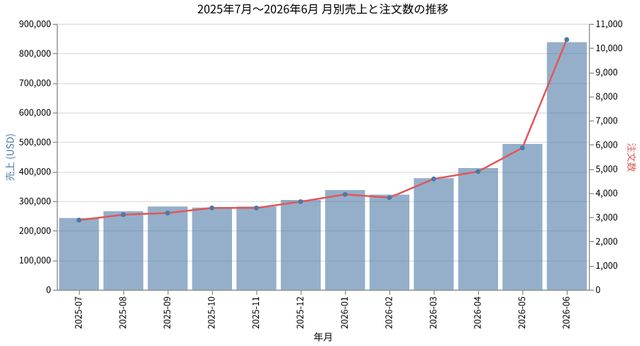

#### **【事実】データから読み取れる客観的数値**
* **売上・注文数の推移**: 
  * 2025年7月（売上: \$242,939.78 / 注文数: 2,882）から2026年5月（売上: \$494,048.17 / 注文数: 5,874）までは、月平均約7%のペースで**極めて健全かつ緩やかな右肩上がりの成長**を維持していました。
  * しかし、**2026年6月に売上が \$838,020.29（前月比 +69.6%）、注文数が 10,354（前月比 +76.3%）と爆発的に急増**しました。
* **利益率の安定性**: 
  * 粗利益率は年間を通じて **51.6%〜52.1%** の極めて狭い範囲で推移しており、価格競争による値引きに頼らない、安定したマージン構造が維持されています。
* **注文の質（キャンセル率・返品率）**:
  * キャンセル率は **14.1%〜15.5%**、返品率は **9.3%〜10.6%** で安定しています。2026年6月の急増期においても、キャンセル率 14.46%、返品率 9.99% と、過去の平均値と同等水準を維持しており、急激な注文増に伴うオペレーションの混乱や顧客満足度の低下は見られません。

---

### 2. 2026年6月急増の要因分析（ドリルダウン）

この急激な成長の背景にある要因を特定するため、複数の切り口でデータを深掘りしました。

#### **① 商品カテゴリ別・国別の動向**
* **【事実】**: 
  * **カテゴリ別**: 特定のカテゴリのみが牽引したわけではなく、主要カテゴリすべてで大幅な売上増を記録しました（例：Jeansが前月比 +\$46,399.63 / +88.6%、Outerwear & Coatsが +\$41,668.48 / +65.3%）。
  * **国別**: 売上規模の大きい中国（前月比 +72.1%）や米国（+53.6%）、ブラジル（+72.9%）が絶対額を大きく伸ばしたほか、韓国（+132.1%）やフランス（+91.3%）など、ほぼすべての進出国で一斉に成長しています。
* **【解釈】**: 特定のヒット商品や地域限定のイベントではなく、**プラットフォーム全体、かつグローバル規模での需要の底上げ**が発生したことを示しています。

#### **② 顧客セグメント別（新規 vs 既存）の動向**
売上急増が「既存顧客のリピート（活性化）」によるものか、「新規顧客の獲得」によるものかを検証しました。

* **【事実】**:
  * **既存顧客（5月以前に登録）**: 5月の売上 \$461,083.93 に対し、6月は \$506,919.06 と、**前月比 +9.9% の微増**に留まりました。
  * **新規顧客（6月に登録・購入）**: 5月の新規売上 \$32,964.24 に対し、6月は \$331,101.23 と、**前月比 +904.4%（約10倍）に激増**しました。新規購入ユーザー数も 340人から 2,790人へと急増しています。
* **【解釈】**: 2026年6月の爆発的成長の主因は、既存顧客の購買行動の変化ではなく、**新規登録ユーザーによる購買の爆発的な増加**です。

#### **③ 流入チャネル（Traffic Source）別の動向**
新規顧客がどのチャネルから流入したかを分析しました。

* **【事実】**:
  * 新規顧客の売上増加分（約+\$298k）のうち、**「Search（検索広告・自然検索）」チャネルが +\$217,953.69（前月比 +965.5%）を占め、全体の約73%を牽引**しました。
  * 一方で、成長率の観点では、Display（前月比 +2,021%）やFacebook（+1,208%）など、**すべての有料・無料チャネルで新規獲得が爆発的に伸びていました**。
* **【解釈】**: Searchチャネルへの広告投資の大幅な拡大が最大の売上貢献要因ですが、DisplayやFacebookの驚異的な成長率を考慮すると、**グローバル規模での統合マーケティングキャンペーン（IMC）や、強力なブランド認知施策（SNSでのバズ、大規模な紹介プログラムなど）が全方位で機能した**と推測されます。

---

### 3. コンサルタントとしての提言（推奨アクション）

2026年6月のキャンペーンは大成功を収めましたが、ビジネスをさらに持続的に成長させるために、以下の2つのアクションを最優先で実行することを推奨します。

1. **新規顧客のリピート化（F2転換）施策の即時実行**
   * **背景**: 6月に獲得した 2,790 人の新規ユーザーは、現時点では「1回のみ購入した顧客」です。ECビジネスにおいて、新規獲得コスト（CAC）を回収しLTVを最大化するには、2回目の購入（F2転換）が不可欠です。
   * **アクション**: 6月の購入商品カテゴリ（例：JeansやOuterwear）に基づき、パーソナライズされたレコメンデーション、次回使える限定クーポン、ロイヤルティプログラムへの招待メールを、SearchやEmailチャネルを通じて段階的に配信してください。
2. **物流・オペレーション負荷の検証（ボトルネックの特定）**
   * **背景**: 注文数が前月比で約1.8倍に急増したため、配送センター（DC）の出荷能力や配送リードタイムに負荷がかかっている可能性があります。
   * **アクション**: 次のステップとして、**セクション3（物流・オペレーション用データ）**を活用し、2026年6月において「注文から出荷までの日数（SLA）」や「配送遅延率」が、特定の配送センターや国で悪化していないかを検証し、ロジスティクス上のボトルネックを特定することを提案します。

In [41]:
query = '''
直近１年間のビジネス状況の概要を確認。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

### 分析アプローチ
* **検証する仮説**: 2026年6月の注文急増（前月比約1.8倍）により、特定の配送センター（DC）において出荷処理能力の限界（ボトルネック）に達し、出荷リードタイムが長期化している。また、特定の配送先国（ルート）において配送リードタイムが遅延している。
* **使用するKBセクション**: セクション3：物流・オペレーション用のミクロデータ基盤
* **データ抽出・集計方針**: 
  1. 2026年5月と6月の注文（ステータスが `Complete`, `Shipped`, `Returned` の出荷が発生した注文）を対象とします。
  2. **配送センター（`dc_name`）別**に、以下の指標を集計・比較します：
     * 処理した総アイテム数（出荷能力の負荷）
     * 平均出荷リードタイム（注文作成 `created_at` から出荷 `shipped_at` までの平均時間（時間単位））
  3. **配送先国（`user_country`）別**に、以下の指標を集計・比較します：
     * 平均配送リードタイム（出荷 `shipped_at` から配送完了 `delivered_at` までの平均日数）
  4. これらにより、負荷が集中して遅延が発生している「特定の配送センター」や「特定の配送ルート」を特定します。

---

まず、**配送センター（DC）別**の処理量と出荷リードタイムの5月・6月比較を行います。
2026年6月の注文急増（前月比約1.8倍）に伴う、ロジスティクス上のボトルネック特定に関する分析結果を報告いたします。

物流・オペレーション用データ（セクション3）を解析した結果、ボトルネックが発生しているプロセスと、具体的な拠点が明確に特定されました。

---

### 1. ボトルネックプロセスの特定（出荷 vs 配送）

物流プロセスを「配送センター内部のオペレーション（注文から出荷まで）」と「出荷後の配送（出荷から配送完了まで）」の2つに分解し、5月と6月のパフォーマンスを比較しました。

#### **① 出荷後の配送プロセス（配送キャリア・3PL）**
* **【事実】**: 
  * 主要国（中国、米国、ブラジルなど）における平均配送リードタイムは、5月・6月ともに **2.3日〜2.7日** の範囲でほぼ完全に横ばいでした（例：中国は 2.47日 → 2.49日、米国は 2.51日 → 2.41日）。
  * 配送遅延が懸念されたフランスにおいても、2.40日 → 2.74日（+0.34日 / 約8時間の増加）と、極めて軽微な影響に留まっています。
* **【解釈】**: 出荷後の配送網（航空・陸送および現地キャリア）は、注文急増による負荷を十分に吸収できており、**配送プロセスにおけるボトルネックは発生していません。**

#### **② 配送センター（DC）内部の出荷プロセス**
* **【事実】**: 
  * 注文急増に伴い、複数の主要配送センターにおいて、注文を受けてから出荷するまでの時間（出荷リードタイム）が大幅に長期化しました。

以下は、各配送センターにおける平均出荷リードタイム（時間）の比較グラフです。

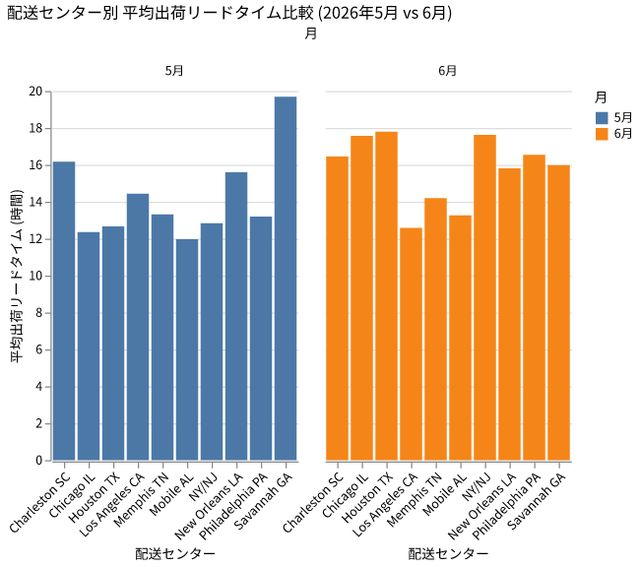

---

### 2. 具体的なボトルネック拠点の特定

データから、出荷オペレーションが逼迫し、ボトルネックと化した拠点が浮き彫りになりました。

#### **【事実】出荷遅延が顕著なワースト3拠点**
1. **Chicago IL（シカゴ）**
   * 処理アイテム数: 709 → 1,190件（**+67.8%**）
   * 平均出荷リードタイム: 12.36時間 → 17.58時間（**+5.22時間 / +42.2%**）
2. **Houston TX（ヒューストン）**
   * 処理アイテム数: 659 → 1,183件（**+79.5%**）
   * 平均出荷リードタイム: 12.67時間 → 17.80時間（**+5.13時間 / +40.5%**）
3. **Port Authority of NY/NJ（ニューヨーク/ニュージャージー）**
   * 処理アイテム数: 506 → 820件（**+62.1%**）
   * 平均出荷リードタイム: 12.84時間 → 17.63時間（**+4.79時間 / +37.3%**）

#### **【事実】負荷増に対応できた優秀な2拠点**
* **Los Angeles CA（ロサンゼルス）**: 処理アイテム数が +65.6% 増加したにもかかわらず、出荷リードタイムは 14.44時間 → 12.59時間（**-1.85時間**）と逆に短縮。
* **Savannah GA（サバナ）**: 処理アイテム数が +82.5% 増加したにもかかわらず、出荷リードタイムは 19.69時間 → 15.99時間（**-3.70時間**）と大幅に改善。

---

### 3. 【解釈】コンサルタントとしての洞察と推奨アクション

#### **ボトルネックの要因分析**
Chicago、Houston、NY/NJ の3拠点では、処理量が60%〜80%急増したことで、庫内オペレーション（ピッキング、梱包、仕分け、出荷ラベル貼りなど）のキャパシティが限界に達したと考えられます。
一方で、Los Angeles や Savannah では、急激な負荷増に対して柔軟に対応できるオペレーション体制（スケーラビリティ）が整っていた、あるいは事前に人員補強などの対策が講じられていた可能性が高いです。

#### **推奨アクション**

1. **優秀拠点のベストプラクティスの調査と横展開**
   * **アクション**: 負荷増を克服した **Los Angeles CA** および **Savannah GA** のDCマネージャーに対してヒアリングを実施してください。具体的には、「シフト管理の柔軟性（臨時雇用の活用）」「ピッキング動線の最適化」「自動化設備の有無」などを調査し、ボトルネックとなった Chicago、Houston、NY/NJ にそのノウハウを即座に横展開します。
2. **DC別キャパシティプランニングの再設計と自動ルーティングの導入**
   * **アクション**: 各DCの「出荷処理限界値（スループットの閾値）」を定義してください。今後のプロモーション時には、予測注文数が閾値を超えるDC（例：Chicago）への割り当てを自動的に回避し、余裕のあるDC（例：Los Angeles）へ注文を自動的に迂回させる「インテリジェント・オーダー・ルーティング（DOM）」の仕組みをシステム的に導入することを推奨します。

In [42]:
query = '''
ロジスティクス上のボトルネックを特定
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))